In [ ]:
from shared.main import *
from shared.fmri import *

import glob
import os
from pathlib import Path
import nibabel as nib
from nilearn.glm.second_level import non_parametric_inference
from nilearn import plotting
from nilearn.image import math_img
from nilearn.glm.second_level import SecondLevelModel, non_parametric_inference

BASE_DIR = '/Users/matty_gee/Desktop/Social/SocialCUD'
ROI_DIR  = f'{BASE_DIR}/masks/ROIs'
gm_img   = nib.load(f"{ROI_DIR}/GM.nii.gz")

# newer: with ctq interactions

In [ ]:
# Subject ID helpers

def canonical_sub_id(x) -> str:
    """
    Normalize subject IDs across forms:
      'sub-01' -> '1'
      '01'     -> '1'
      1        -> '1'
      'sub-123_foo.nii.gz' -> '123'
    """
    s = str(x)
    s = Path(s).name
    s = s.split("_")[0]
    s = s.replace("sub-", "")

    if s.isdigit():
        return str(int(s))

    return s

def parse_sub_id(path: str) -> str:
    """
    Extract canonical sub_id from a path like:
      .../sub-01_foo.nii.gz
      .../sub-123_foo.nii.gz
    """
    return canonical_sub_id(path)

def find_sl_imgs(
    sl_dir: str,
    sl_fname_pattern: str,
    incl_subs: set[str] | None = None,
) -> dict:
    """
    Find searchlight images matching pattern, optionally filter by incl_subs.

    Returns dict with:
      - sub_ids
      - imgs
    """
    sl_dir = str(sl_dir)
    paths = sorted(glob.glob(os.path.join(sl_dir, f"*{sl_fname_pattern}*")))

    if incl_subs is not None:
        incl_subs_canon = {canonical_sub_id(s) for s in incl_subs}
        paths = [p for p in paths if parse_sub_id(p) in incl_subs_canon]

    sub_ids = [parse_sub_id(p) for p in paths]

    if len(paths) == 0:
        raise ValueError(f"No images found in {sl_dir} matching pattern '*{sl_fname_pattern}*'.")

    if len(set(sub_ids)) != len(sub_ids):
        duplicated = pd.Series(sub_ids).value_counts()
        duplicated = duplicated[duplicated > 1]
        raise ValueError(f"Duplicate subject IDs found in searchlight images:\n{duplicated}")

    print(f"[find_sl_imgs] Found {len(paths)} images")
    print(f"[find_sl_imgs] First 5 sub_ids: {sub_ids[:5]}")

    return {
        "sub_ids": sub_ids,
        "imgs": paths,
    }

# Design matrix helpers

def _zscore(vals: np.ndarray) -> np.ndarray:
    vals = np.asarray(vals, dtype=float)
    mu = np.nanmean(vals)
    sd = np.nanstd(vals, ddof=1)
    return (vals - mu) / sd if np.isfinite(sd) and sd > 0 else vals - mu

def _center(vals: np.ndarray) -> np.ndarray:
    vals = np.asarray(vals, dtype=float)
    return vals - np.nanmean(vals)

def _safe_interaction_name(parts: list[str]) -> str:
    return "_x_".join(parts)

def _split_formula_terms(covariates: list[str] | str | None) -> list[str]:
    """
    Accepts:
      None
      "dx * ctq_score + sex + fd_mean"
      ["dx * ctq_score", "sex", "fd_mean"]

    Returns top-level additive terms.
    """
    if covariates is None:
        return []

    if isinstance(covariates, str):
        covariates = [covariates]

    terms = []
    for item in covariates:
        item = str(item).strip()
        if not item:
            continue

        # Split on + at top level. This is intentionally simple.
        for term in item.split("+"):
            term = term.strip()
            if term:
                terms.append(term)

    return terms

def _expand_covariate_terms(covariates: list[str] | str | None) -> tuple[list[str], list[tuple[str, ...]]]:
    """
    Parse simple formula-like terms.

    Supported:
      "a"       -> main effect a
      "a + b"   -> main effects a, b
      "a:b"     -> interaction only
      "a * b"   -> main effects a, b, and interaction a:b
      "a*b*c"   -> main effects a, b, c, and full interaction a:b:c

    Returns
    -------
    base_terms : list[str]
        Main-effect variables needed.
    interaction_terms : list[tuple[str, ...]]
        Interaction terms represented as tuples.
    """
    raw_terms = _split_formula_terms(covariates)

    base_terms = []
    interaction_terms = []

    def add_base(x):
        x = x.strip()
        if x and x not in base_terms:
            base_terms.append(x)

    def add_interaction(parts):
        parts = tuple(p.strip() for p in parts if p.strip())
        if len(parts) < 2:
            raise ValueError(f"Interaction must have at least two variables. Got: {parts}")
        if parts not in interaction_terms:
            interaction_terms.append(parts)

    for term in raw_terms:
        # a * b means a + b + a:b
        if "*" in term:
            parts = [p.strip() for p in term.split("*") if p.strip()]
            if len(parts) < 2:
                raise ValueError(f"Invalid '*' term: {term}")

            for p in parts:
                add_base(p)

            add_interaction(parts)

        # a:b means interaction only
        elif ":" in term:
            parts = [p.strip() for p in term.split(":") if p.strip()]
            if len(parts) < 2:
                raise ValueError(f"Invalid ':' term: {term}")

            for p in parts:
                add_base(p)

            add_interaction(parts)

        # simple main effect
        else:
            add_base(term)

    return base_terms, interaction_terms

def _reaction_time_diff(sub_id: str) -> float:
    """
    Computes |mean RT_affil - mean RT_power| using load_behavior(...).

    Requires load_behavior(sub_id, neutrals=False) to exist in namespace.
    """
    try:
        behav = load_behavior(sub_id, neutrals=False)
    except NameError as e:
        raise NameError(
            "Covariate 'reaction_time' requested, but load_behavior(...) is not defined "
            "in the current namespace."
        ) from e

    behav = behav.loc[behav["responded"]]
    m = behav.groupby("dimension")["reaction_time"].mean()

    return float(abs(m.get("affil", np.nan) - m.get("power", np.nan)))

def _prepare_subject_covariate_table(
    data: pd.DataFrame,
    sub_ids: list[str],
    required_cols: list[str],
    *,
    sub_col: str = "sub_id",
) -> pd.DataFrame:
    """
    Returns rows of data matched to image order.
    """
    if data is None:
        raise ValueError("`data` must be provided for non-derived covariates.")

    if sub_col not in data.columns:
        raise ValueError(f"`data` must contain subject column '{sub_col}'.")

    missing_cols = [c for c in required_cols if c != "reaction_time" and c not in data.columns]
    if missing_cols:
        raise ValueError(f"`data` is missing columns: {missing_cols}")

    df = data.copy()
    df["_sub_id_canon"] = df[sub_col].apply(canonical_sub_id)

    # If repeated rows exist per subject, keep one row only if covariates are invariant.
    check_cols = [c for c in required_cols if c != "reaction_time"]

    if check_cols:
        nunique = df.groupby("_sub_id_canon")[check_cols].nunique(dropna=False)
        bad = nunique[(nunique > 1).any(axis=1)]

        if len(bad) > 0:
            raise ValueError(
                "Some subjects have multiple different covariate values across rows. "
                "Collapse `data` to one row per subject first.\n"
                f"{bad}"
            )

    df = df.drop_duplicates("_sub_id_canon").set_index("_sub_id_canon")

    sub_ids_canon = [canonical_sub_id(s) for s in sub_ids]
    missing_subs = sorted(set(sub_ids_canon) - set(df.index))

    if missing_subs:
        raise ValueError(f"Subjects in images but missing from data: {missing_subs}")

    return df.loc[sub_ids_canon].copy()

def _to_numeric_or_binary_series(vals, varname: str) -> np.ndarray:
    """
    Convert values to numeric if possible. Allows common binary string labels.
    """
    s = pd.Series(vals)

    # First try numeric.
    numeric = pd.to_numeric(s, errors="coerce")
    if numeric.notna().all():
        return numeric.astype(float).to_numpy()

    # Then try common binary labels.
    lower = s.astype(str).str.lower().str.strip()

    label_map = {
        "hc": 0.0,
        "control": 0.0,
        "controls": 0.0,
        "healthy": 0.0,
        "healthy control": 0.0,
        "healthy controls": 0.0,

        "cd": 1.0,
        "cud": 1.0,
        "patient": 1.0,
        "patients": 1.0,
        "clinical": 1.0,
        "case": 1.0,
        "cases": 1.0,
    }

    mapped = lower.map(label_map)
    if mapped.notna().all():
        return mapped.astype(float).to_numpy()

    raise ValueError(
        f"Could not convert covariate '{varname}' to numeric. "
        "Use numeric coding or add a mapping in `_to_numeric_or_binary_series`."
    )

def _transform_covariate(
    vals: np.ndarray,
    varname: str,
    *,
    effect_code_cols: set[str],
    center_cols: set[str],
    no_scale_cols: set[str],
    zscore_cols: set[str] | None,
) -> np.ndarray:
    """
    Transform one base covariate.

    Defaults:
      - effect_code_cols: binary effect-code, e.g. dx 0/1 -> -0.5/+0.5
      - center_cols: mean center
      - no_scale_cols: no transform
      - zscore_cols=None: all other numeric variables are z-scored
    """
    vals = _to_numeric_or_binary_series(vals, varname)

    if np.isnan(vals).any():
        raise ValueError(f"NaNs found in covariate '{varname}'.")

    if varname in no_scale_cols:
        return vals.astype(float)

    if varname in effect_code_cols:
        unique = sorted(np.unique(vals))

        if len(unique) != 2:
            raise ValueError(
                f"Covariate '{varname}' was requested as effect-coded, "
                f"but it does not have exactly two unique values. Found: {unique}"
            )

        lo, hi = unique
        out = np.where(vals == lo, -0.5, 0.5).astype(float)

        print(f"[design] Effect-coded {varname}: {lo} -> -0.5, {hi} -> +0.5")
        return out

    if varname in center_cols:
        return _center(vals)

    if zscore_cols is not None:
        if varname in zscore_cols:
            return _zscore(vals)
        else:
            return vals.astype(float)

    # Default: z-score all non-effect-coded continuous covariates.
    return _zscore(vals)

def build_design_matrix(
    sub_ids: list[str],
    covariates: list[str] | str | None = None,
    *,
    data: pd.DataFrame | None = None,
    sub_col: str = "sub_id",
    add_intercept: bool = True,
    effect_code_cols: set[str] | None = None,
    center_cols: set[str] | None = None,
    no_scale_cols: set[str] | None = None,
    zscore_cols: set[str] | None = None,
    check_rank: bool = True,
) -> pd.DataFrame:
    """
    Build a second-level design matrix.

    Parameters
    ----------
    sub_ids : list[str]
        Subject IDs in the exact same order as imgs.

    covariates : list[str] | str | None
        Formula-like covariate specification.

        Examples:
            ["dx", "ctq_score", "sex", "memory_mean", "fd_mean"]
            ["dx * ctq_score", "sex", "memory_mean", "fd_mean"]
            "dx * ctq_score + sex + memory_mean + fd_mean"
            "dx + ctq_score + dx:ctq_score + sex"

        Supported syntax:
            "+" separates terms
            "*" expands to main effects plus interaction
            ":" creates interaction

    data : pd.DataFrame
        Must contain sub_col and all non-derived covariates.

    Transform defaults
    ------------------
    effect_code_cols defaults to {"dx"}:
        binary dx is coded -0.5/+0.5.
        If dx is 0/1, then 0 -> -0.5 and 1 -> +0.5.
        This makes the interaction interpretable as slope difference.

    center_cols defaults to {"sex"}:
        sex is mean-centered by default rather than z-scored.

    all other covariates:
        z-scored by default.

    Notes
    -----
    If covariates contains "dx * ctq_score", columns become:
        intercept
        dx
        ctq_score
        dx_x_ctq_score

    The interaction is computed after transforming the base columns.
    Thus dx_x_ctq_score = effect-coded dx * z-scored ctq_score by default.
    """
    sub_ids = [canonical_sub_id(s) for s in sub_ids]
    effect_code_cols = set(effect_code_cols or {"dx"})
    center_cols = set(center_cols or {"sex"})
    no_scale_cols = set(no_scale_cols or set())

    base_terms, interaction_terms = _expand_covariate_terms(covariates)

    dm = pd.DataFrame(index=np.arange(len(sub_ids)))

    if add_intercept:
        dm["intercept"] = 1.0

    # Prepare covariate table if needed.
    table = None
    nonderived_terms = [t for t in base_terms if t != "reaction_time"]

    if nonderived_terms:
        table = _prepare_subject_covariate_table(
            data=data,
            sub_ids=sub_ids,
            required_cols=nonderived_terms,
            sub_col=sub_col,
        )

    # Add base terms.
    for term in base_terms:
        if term == "intercept":
            continue

        if term == "reaction_time":
            raw_vals = np.array([_reaction_time_diff(sid) for sid in sub_ids], dtype=float)
        else:
            raw_vals = table[term].to_numpy()

        dm[term] = _transform_covariate(
            raw_vals,
            term,
            effect_code_cols=effect_code_cols,
            center_cols=center_cols,
            no_scale_cols=no_scale_cols,
            zscore_cols=zscore_cols,
        )

    # Add interaction terms from already-transformed base terms.
    for parts in interaction_terms:
        missing = [p for p in parts if p not in dm.columns]
        if missing:
            raise ValueError(f"Cannot build interaction {parts}; missing base columns: {missing}")

        name = _safe_interaction_name(list(parts))
        vals = np.ones(len(dm), dtype=float)

        for p in parts:
            vals = vals * dm[p].to_numpy(dtype=float)

        dm[name] = vals

    # Validate.
    if dm.isna().any().any():
        bad_cols = dm.columns[dm.isna().any()].tolist()
        bad_rows = np.where(dm.isna().any(axis=1))[0].tolist()
        bad_subs = [sub_ids[i] for i in bad_rows]
        raise ValueError(f"NaNs in design matrix columns {bad_cols} for subjects {bad_subs}")

    if check_rank:
        X = dm.to_numpy(dtype=float)
        rank = np.linalg.matrix_rank(X)

        if rank < X.shape[1]:
            raise ValueError(
                f"Design matrix is rank deficient: rank={rank}, columns={X.shape[1]}.\n"
                f"Columns: {dm.columns.tolist()}\n"
                "Likely causes: duplicate covariates, empty group, perfectly collinear covariates, "
                "or interaction term confounded with main effects."
            )

    print("\n[build_design_matrix] Columns:")
    print(dm.columns.tolist())

    print("\n[build_design_matrix] Summary:")
    print(dm.describe().T[["mean", "std", "min", "max"]])

    return dm

# Contrast helpers
def _coerce_to_logp_img(npi_out):
    """
    Return a Nifti1Image of -log10(p_FWER) from nilearn non_parametric_inference output.
    """
    if isinstance(npi_out, nib.Nifti1Image):
        return npi_out

    if isinstance(npi_out, dict):
        for k in ["logp_max_t", "logp_max_mass", "logp_max_tfce"]:
            if k in npi_out and isinstance(npi_out[k], nib.Nifti1Image):
                return npi_out[k]

        for v in npi_out.values():
            if isinstance(v, nib.Nifti1Image):
                return v

    raise TypeError(f"Cannot coerce non_parametric_inference output type: {type(npi_out)}")

def make_contrast_vector(
    design_matrix: pd.DataFrame,
    contrast: str = "intercept",
    tail: str | None = "greater",
) -> np.ndarray:
    """
    Make a simple one-column contrast vector.

    For more complex contrasts, pass string contrasts directly to nilearn, e.g.:
        "ctq_score + 0.5*dx_x_ctq_score"
    """
    cols = list(design_matrix.columns)

    if contrast not in cols:
        raise ValueError(f"Contrast '{contrast}' not found in design matrix columns: {cols}")

    v = np.zeros(len(cols), dtype=float)
    v[cols.index(contrast)] = 1.0

    if tail is None or tail == "greater":
        return v
    elif tail == "less":
        return -v
    else:
        raise ValueError("tail must be None, 'greater', or 'less'")

def make_contrast(
    design_matrix: pd.DataFrame,
    contrast: str,
    *,
    tail: str | None = None,
):
    """
    Returns either:
      - the original contrast string, if it is a valid formula contrast
      - a vector, if you request one-column contrast with tail='less'

    Use this mostly for convenience.
    """
    if tail == "less":
        return make_contrast_vector(design_matrix, contrast=contrast, tail="less")

    return contrast

# Second-level model runners
def run_perm_second_level(
    imgs: list[str],
    design_matrix: pd.DataFrame,
    *,
    mask_img=None,
    contrast=None,
    contrast_vec: np.ndarray | None = None,
    fwhm: float | None = 8.0,
    n_perm: int = 5000,
    two_sided: bool = False,
    tfce: bool = False,
    threshold=None,
    random_state: int = 2022,
):
    """
    Runs nilearn's permutation inference and returns a -log10(p_FWER) image.

    Accepts either:
      contrast="dx_x_ctq_score"
      contrast="ctq_score + 0.5*dx_x_ctq_score"
      contrast_vec=np.array(...)
    """
    if (contrast is None) == (contrast_vec is None):
        raise ValueError("Provide exactly one of `contrast` or `contrast_vec`.")

    second_level_contrast = contrast if contrast is not None else contrast_vec

    out = non_parametric_inference(
        imgs,
        design_matrix=design_matrix,
        second_level_contrast=second_level_contrast,
        mask=mask_img,
        smoothing_fwhm=fwhm,
        n_perm=n_perm,
        two_sided_test=two_sided,
        tfce=tfce,
        threshold=threshold,
        model_intercept=False,
        random_state=random_state,
        n_jobs=-1,
        verbose=1,
    )

    return _coerce_to_logp_img(out)

def fit_second_level_model(
    imgs: list[str],
    design_matrix: pd.DataFrame,
    *,
    mask_img=None,
    fwhm: float | None = 8.0,
):
    """
    Fit and return a nilearn SecondLevelModel.
    """
    if len(imgs) != len(design_matrix):
        raise ValueError(
            f"Number of images ({len(imgs)}) does not match design matrix rows ({len(design_matrix)})."
        )

    slm = SecondLevelModel(
        mask_img=mask_img,
        smoothing_fwhm=fwhm,
        n_jobs=-1,
        minimize_memory=False,
    )

    slm = slm.fit(
        second_level_input=imgs,
        design_matrix=design_matrix,
    )

    return slm

def run_parametric_second_level(
    imgs: list[str],
    design_matrix: pd.DataFrame,
    *,
    mask_img=None,
    contrast=None,
    contrast_vec: np.ndarray | None = None,
    fwhm: float | None = 8.0,
    output_type: str = "z_score",
):
    """
    Standard parametric second-level GLM using nilearn.

    Accepts either:
      contrast="dx"
      contrast="dx_x_ctq_score"
      contrast="ctq_score + 0.5*dx_x_ctq_score"
      contrast_vec=np.array(...)

    Useful output_type values:
      "z_score"
      "stat"
      "p_value"
      "effect_size"
      "effect_variance"
    """
    if (contrast is None) == (contrast_vec is None):
        raise ValueError("Provide exactly one of `contrast` or `contrast_vec`.")

    slm = fit_second_level_model(
        imgs,
        design_matrix,
        mask_img=mask_img,
        fwhm=fwhm,
    )

    second_level_contrast = contrast if contrast is not None else contrast_vec

    out_img = slm.compute_contrast(
        second_level_contrast=second_level_contrast,
        output_type=output_type,
    )

    return out_img

def run_parametric_second_level_with_logp(
    imgs: list[str],
    design_matrix: pd.DataFrame,
    *,
    mask_img=None,
    contrast=None,
    contrast_vec: np.ndarray | None = None,
    fwhm: float | None = 8.0,
):
    """
    Parametric second-level GLM returning:
      - z_img
      - logp_img = -log10(parametric p-value)
    """
    if (contrast is None) == (contrast_vec is None):
        raise ValueError("Provide exactly one of `contrast` or `contrast_vec`.")

    slm = fit_second_level_model(
        imgs,
        design_matrix,
        mask_img=mask_img,
        fwhm=fwhm,
    )

    second_level_contrast = contrast if contrast is not None else contrast_vec

    z_img = slm.compute_contrast(
        second_level_contrast=second_level_contrast,
        output_type="z_score",
    )

    p_img = slm.compute_contrast(
        second_level_contrast=second_level_contrast,
        output_type="p_value",
    )

    logp_img = math_img("-np.log10(np.maximum(img, 1e-300))", img=p_img)

    return z_img, logp_img


In [ ]:
def save_stat_map_crosscuts(
    img,
    out_png,
    *,
    title: str,
    threshold=0,
    cmap="RdBu_r",
    symmetric_cbar=True,
    black_bg=False,
    display_mode="ortho",
    cut_coords=None,
    dpi=300,
):
    display = plotting.plot_stat_map(
        img,
        threshold=threshold,
        cmap=cmap,
        symmetric_cbar=symmetric_cbar,
        black_bg=black_bg,
        draw_cross=False,
        display_mode=display_mode,
        cut_coords=cut_coords,
        title=title,
    )

    display.savefig(str(out_png), dpi=dpi)
    display.close()

    return display

def sanitize_name(x: str) -> str:
    """
    Safe filename stem for contrast names.
    """
    x = str(x)
    x = x.replace(" ", "")
    x = x.replace("*", "x")
    x = x.replace(":", "_x_")
    x = x.replace("+", "_plus_")
    x = x.replace("-", "_minus_")
    x = x.replace("/", "_")
    x = re.sub(r"[^A-Za-z0-9_.-]+", "_", x)
    return x

# ------------------------------------------------------------
# Find images
# ------------------------------------------------------------

FNAME_PATTERN = "dimension"
LSS_DIR = "/Users/matty_gee/Desktop/Social/SocialCUD/analyses/lss_decision/"
SL_DIR = f"{LSS_DIR}/searchlight-maps/{FNAME_PATTERN}/"
OUT_DIR = Path(f"{LSS_DIR}/statistical-maps/{FNAME_PATTERN}")
OUT_DIR.mkdir(parents=True, exist_ok=True)

sl_dict = find_sl_imgs(
    SL_DIR,
    FNAME_PATTERN,
    incl_subs={str(s) for s in incl_subs},
)

# ------------------------------------------------------------
# Build design matrix
# Defaults:
#   "dx * ctq_score" -> dx + ctq_score + dx_x_ctq_score
#   dx is effect-coded: 0 -> -0.5, 1 -> +0.5
#   ctq_score is z-scored
#   sex is mean-centered
#   memory_mean and fd_mean are z-scored
# ------------------------------------------------------------

covariates = ["dx * ctq_score",
    "sex",
    "memory_mean",
    "fd_mean",
]

dmatrix = build_design_matrix(
    sub_ids=sl_dict["sub_ids"],
    data=data,
    covariates=covariates,
    sub_col="sub_id",
    effect_code_cols={"dx"},
    center_cols={"sex"},
)

dmatrix.to_csv(OUT_DIR / "design_matrix.csv", index=False)

# ------------------------------------------------------------
# Define contrasts
# Because dx is effect-coded:
#   dx = -0.5 for HC
#   dx = +0.5 for CD
#
# dx_x_ctq_score tests:
#   CTQ slope in CD - CTQ slope in HC
#
# Simple CTQ slopes:
#   HC slope = ctq_score - 0.5 * dx_x_ctq_score
#   CD slope = ctq_score + 0.5 * dx_x_ctq_score
# ------------------------------------------------------------

contrasts = {
    "intercept": "intercept",

    # CD > HC at mean CTQ
    "dx_CD_gt_HC_at_mean_CTQ": "dx",

    # Average CTQ slope across groups
    "ctq_average_slope": "ctq_score",

    # Main interaction of interest
    "ctq_x_dx_slope_difference": "dx_x_ctq_score",

    # Simple slopes
    "ctq_slope_HC": "ctq_score - 0.5*dx_x_ctq_score",
    "ctq_slope_CD": "ctq_score + 0.5*dx_x_ctq_score",
}

# ------------------------------------------------------------
# Run parametric second-level GLMs and save unthresholded z-maps
# ------------------------------------------------------------

for name, contrast in contrasts.items():

    print(f"\nRunning parametric contrast: {name} = {contrast}")

    zimg = run_parametric_second_level(
        sl_dict["imgs"],
        dmatrix,
        mask_img=None,
        contrast=contrast,
        fwhm=0,
        output_type="z_score",
    )

    safe = sanitize_name(name)
    map_path = OUT_DIR / f"{safe}_zmap_unthresholded.nii.gz"
    nib.save(zimg, str(map_path))

    png_path = OUT_DIR / f"{safe}_zmap_crosscuts.png"
    save_stat_map_crosscuts(
        zimg,
        png_path,
        threshold=0,
        cmap="RdBu_r",
        symmetric_cbar=True,
        black_bg=False,
        display_mode="ortho",
        cut_coords=None,
        title=f"{FNAME_PATTERN}: {name}",
    )

# ------------------------------------------------------------
# Permutation inference for CTQ x Dx interaction
# For the interaction, use two-sided=True unless you have a strong directional hypothesis.
# ------------------------------------------------------------

RUN_PERMUTATION = True
if RUN_PERMUTATION:

    interaction_contrast = "dx_x_ctq_score"

    print(f"\nRunning permutation inference for: {interaction_contrast}")

    logp_img = run_perm_second_level(
        sl_dict["imgs"],
        dmatrix,
        mask_img=None,
        contrast=interaction_contrast,
        fwhm=0,
        n_perm=5000,
        two_sided=True,
        tfce=False,
        threshold=None,
        random_state=2022,
    )

    map_path = OUT_DIR / f"{interaction_contrast}_slope_difference_logp_FWER.nii.gz"
    png_path = OUT_DIR / f"{interaction_contrast}_slope_difference_logp_FWER_crosscuts.png"

    nib.save(logp_img, str(map_path))

    save_stat_map_crosscuts(
        logp_img,
        png_path,
        threshold=-np.log10(0.05),
        cmap="inferno",
        symmetric_cbar=False,
        black_bg=False,
        display_mode="ortho",
        cut_coords=None,
        title=f"{FNAME_PATTERN}: CTQ x Dx -log10 FWER p",
    )

    print(f"Saved: {map_path}")
    print(f"Saved: {png_path}")

[find_sl_imgs] Found 61 images
[find_sl_imgs] First 5 sub_ids: ['18001', '18002', '18003', '18004', '18005']
[design] Effect-coded dx: 0.0 -> -0.5, 1.0 -> +0.5

[build_design_matrix] Columns:
['intercept', 'dx', 'ctq_score', 'sex', 'memory_mean', 'fd_mean', 'dx_x_ctq_score']

[build_design_matrix] Summary:
                        mean       std       min       max
intercept       1.000000e+00  0.000000  1.000000  1.000000
dx             -4.098361e-02  0.502453 -0.500000  0.500000
ctq_score      -3.822079e-17  1.000000 -1.033754  3.076437
sex             2.002042e-17  0.484176 -0.360656  0.639344
memory_mean    -4.404491e-16  1.000000 -1.457122  2.091159
fd_mean         1.365028e-16  1.000000 -1.337649  3.737059
dx_x_ctq_score  7.428388e-02  0.494358 -1.430056  1.538218

Saved design matrix: /Users/matty_gee/Desktop/Social/SocialCUD/analyses/lss_decision/statistical-maps/dimension/design_matrix.csv

Running parametric contrast: intercept = intercept
Saved: /Users/matty_gee/Desktop/Socia

[non_parametric_inference] Fitting second level model...

[non_parametric_inference] 
Computation of second level model done in 0.2052311897277832 seconds

Saved: /Users/matty_gee/Desktop/Social/SocialCUD/analyses/lss_decision/statistical-maps/dimension/ctq_x_dx_slope_difference_logp_FWER.nii.gz
Saved: /Users/matty_gee/Desktop/Social/SocialCUD/analyses/lss_decision/statistical-maps/dimension/ctq_x_dx_slope_difference_logp_FWER_crosscuts.png



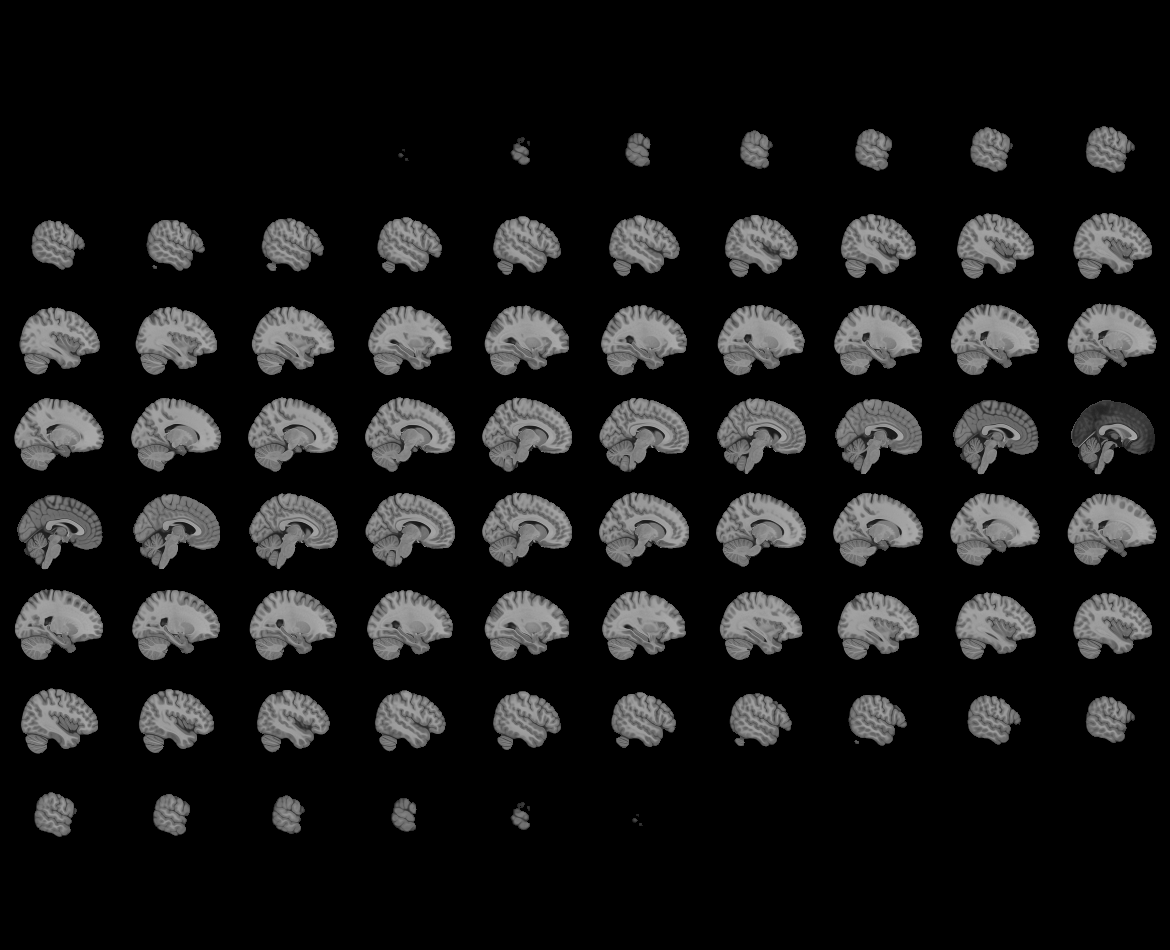
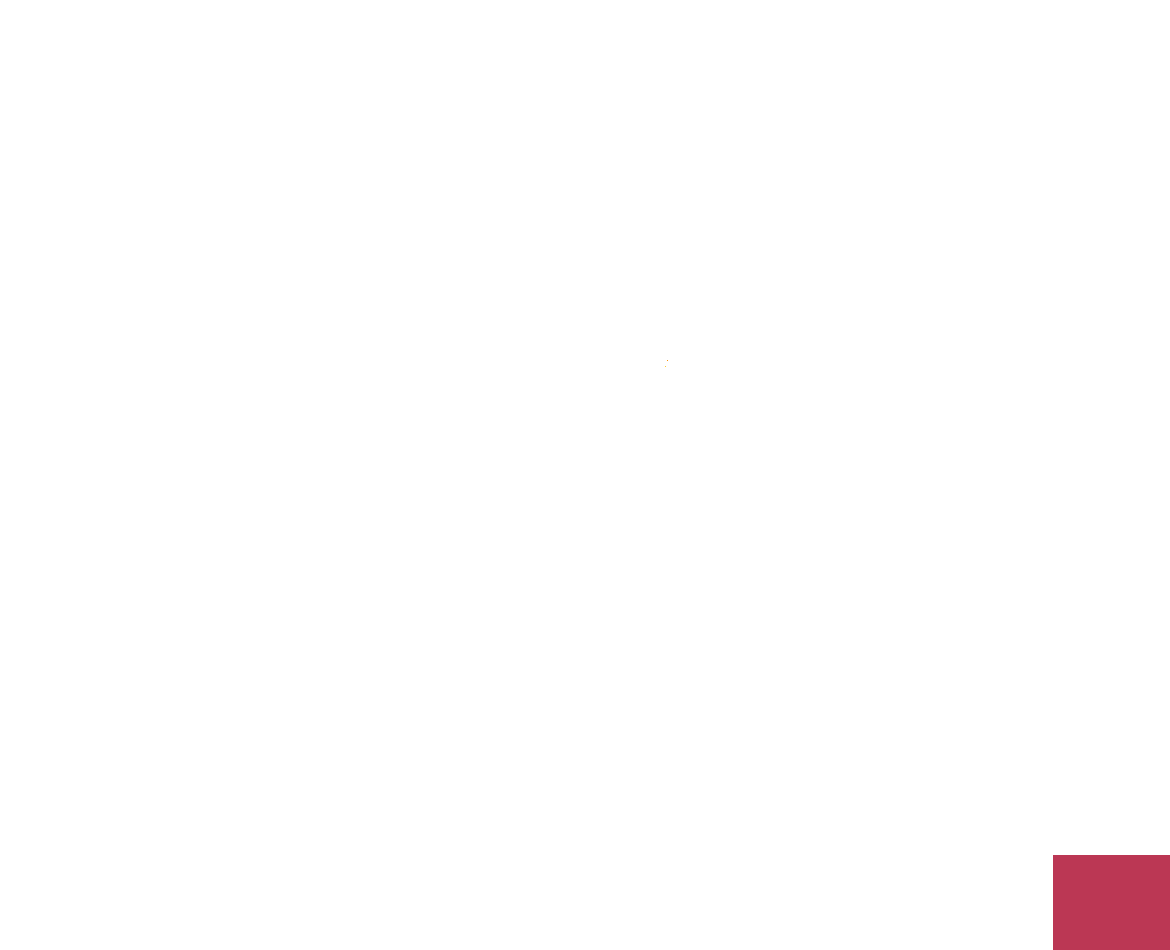

In [ ]:
map_path = OUT_DIR / "dx_x_ctq_score_slope_difference_logp_FWER.nii.gz"
plotting.view_img(str(map_path), threshold=-np.log10(0.5), cmap="inferno")

### ctq interactions

Saving CTQ interaction analyses to: /Users/matty_gee/Desktop/Social/SocialCUD/analyses/lss_decision/statistical-maps/dimension/ctq_interaction_analysis

Found CTQ maps:
  ctq_average_slope: /Users/matty_gee/Desktop/Social/SocialCUD/analyses/lss_decision/statistical-maps/dimension/ctq_average_slope_zmap_unthresholded.nii.gz
  ctq_x_dx_slope_difference: /Users/matty_gee/Desktop/Social/SocialCUD/analyses/lss_decision/statistical-maps/dimension/ctq_x_dx_slope_difference_zmap_unthresholded.nii.gz
  ctq_slope_HC: /Users/matty_gee/Desktop/Social/SocialCUD/analyses/lss_decision/statistical-maps/dimension/ctq_slope_HC_zmap_unthresholded.nii.gz
  ctq_slope_CD: /Users/matty_gee/Desktop/Social/SocialCUD/analyses/lss_decision/statistical-maps/dimension/ctq_slope_CD_zmap_unthresholded.nii.gz
Saved views for: ctq_average_slope
Saved views for: ctq_x_dx_slope_difference
Saved views for: ctq_slope_HC
Saved views for: ctq_slope_CD

ctq_average_slope: cluster table


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,1,-62.5,-30.5,-32.5,-4.192903,104
1,2,-42.5,-34.5,-6.5,-3.655851,1280
2,2a,-34.5,-32.5,-2.5,-2.930226,
3,2b,-40.5,-42.5,-2.5,-2.919682,
4,2c,-34.5,-36.5,-2.5,-2.903660,
5,3,-46.5,-10.5,-42.5,-3.646321,352
6,4,-70.5,-44.5,17.5,-3.362543,120
7,5,-0.5,-72.5,-2.5,-3.248132,1904
8,5a,9.5,-72.5,-0.5,-3.043074,
9,5b,-8.5,-74.5,-2.5,-2.961841,


Saved: /Users/matty_gee/Desktop/Social/SocialCUD/analyses/lss_decision/statistical-maps/dimension/ctq_interaction_analysis/ctq_average_slope_clusters_zgt_2p58_k10.csv

ctq_x_dx_slope_difference: cluster table


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,1,-28.5,25.5,-46.5,4.077114,1504
1,1a,-28.5,29.5,-34.5,4.013265,
2,1b,-30.5,31.5,-42.5,3.579422,
3,1c,-30.5,21.5,-46.5,3.449849,
4,2,-36.5,-78.5,-58.5,3.628698,1024
5,2a,-46.5,-74.5,-54.5,3.467440,
6,2b,-10.5,-90.5,-54.5,3.382444,
7,2c,-42.5,-74.5,-60.5,3.382444,
8,3,-36.5,-96.5,-24.5,3.429064,328
9,3a,-34.5,-98.5,-34.5,3.382444,


Saved: /Users/matty_gee/Desktop/Social/SocialCUD/analyses/lss_decision/statistical-maps/dimension/ctq_interaction_analysis/ctq_x_dx_slope_difference_clusters_zgt_2p58_k10.csv

ctq_slope_HC: cluster table


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,1,45.5,-34.5,39.5,3.042890,384
1,1,-28.5,25.5,-46.5,-5.394510,1808
2,1a,-32.5,31.5,-34.5,-4.384395,
3,1b,-38.5,27.5,-44.5,-3.899410,
4,1c,-24.5,25.5,-32.5,-3.372996,
5,2,-34.5,-76.5,-60.5,-4.463122,1248
6,2a,-44.5,-74.5,-56.5,-4.432476,
7,2b,-28.5,-84.5,-58.5,-4.431483,
8,2c,-10.5,-90.5,-54.5,-4.431483,
9,3,47.5,-60.5,-56.5,-4.432846,184


Saved: /Users/matty_gee/Desktop/Social/SocialCUD/analyses/lss_decision/statistical-maps/dimension/ctq_interaction_analysis/ctq_slope_HC_clusters_zgt_2p58_k10.csv

ctq_slope_CD: cluster table


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,1,33.5,29.5,57.5,3.874136,1608
1,1a,19.5,23.5,49.5,3.161819,
2,1b,31.5,25.5,49.5,2.801970,
3,1c,19.5,23.5,55.5,2.801866,
4,2,47.5,-74.5,37.5,2.961961,344
5,2a,45.5,-72.5,45.5,2.764864,
6,1,-20.5,-48.5,-38.5,-3.362249,656
7,1a,-18.5,-56.5,-36.5,-2.981886,
8,2,11.5,-54.5,-42.5,-2.857602,80


Saved: /Users/matty_gee/Desktop/Social/SocialCUD/analyses/lss_decision/statistical-maps/dimension/ctq_interaction_analysis/ctq_slope_CD_clusters_zgt_2p58_k10.csv

Saved subject-level design: /Users/matty_gee/Desktop/Social/SocialCUD/analyses/lss_decision/statistical-maps/dimension/ctq_interaction_analysis/subject_level_design_for_ctq_interaction.csv


,sub_id,img,intercept,dx,ctq_score,sex,memory_mean,fd_mean,dx_x_ctq_score,dx_raw,ctq_score_raw,sex_raw,memory_mean_raw,fd_mean_raw,dx_label
0,18001,/Users/matty_gee/Desktop/Social/SocialCUD/anal...,1.0,-0.5,-0.925591,-0.360656,1.736331,-1.171251,0.462795,0,27,0,0.833333,0.117748,HC
1,18002,/Users/matty_gee/Desktop/Social/SocialCUD/anal...,1.0,-0.5,-0.492939,0.639344,-0.924880,-1.046961,0.246470,0,35,1,0.333333,0.132037,HC
2,18003,/Users/matty_gee/Desktop/Social/SocialCUD/anal...,1.0,-0.5,-0.060288,-0.360656,-0.215224,-0.463992,0.030144,0,43,0,0.466667,0.199058,HC
3,18004,/Users/matty_gee/Desktop/Social/SocialCUD/anal...,1.0,0.5,0.913179,-0.360656,-1.279708,0.986539,0.456589,1,61,0,0.266667,0.365818,CD
4,18005,/Users/matty_gee/Desktop/Social/SocialCUD/anal...,1.0,-0.5,-0.925591,-0.360656,-1.102294,0.050129,0.462795,0,27,0,0.300000,0.258164,HC



Top CTQ × Dx interaction peaks:


,x,y,z,stat
0,-28.5,25.5,-46.5,4.077114
1,-28.5,29.5,-34.5,4.013265
2,-36.5,-78.5,-58.5,3.628698
3,-30.5,31.5,-42.5,3.579422
4,-46.5,-74.5,-54.5,3.467440
5,-30.5,21.5,-46.5,3.449849
6,-36.5,-96.5,-24.5,3.429064
7,-10.5,-90.5,-54.5,3.382444


Saved: /Users/matty_gee/Desktop/Social/SocialCUD/analyses/lss_decision/statistical-maps/dimension/ctq_interaction_analysis/top_ctq_x_dx_interaction_peaks.csv

Saved peak sphere extractions: /Users/matty_gee/Desktop/Social/SocialCUD/analyses/lss_decision/statistical-maps/dimension/ctq_interaction_analysis/ctq_x_dx_peak_sphere_extractions.csv


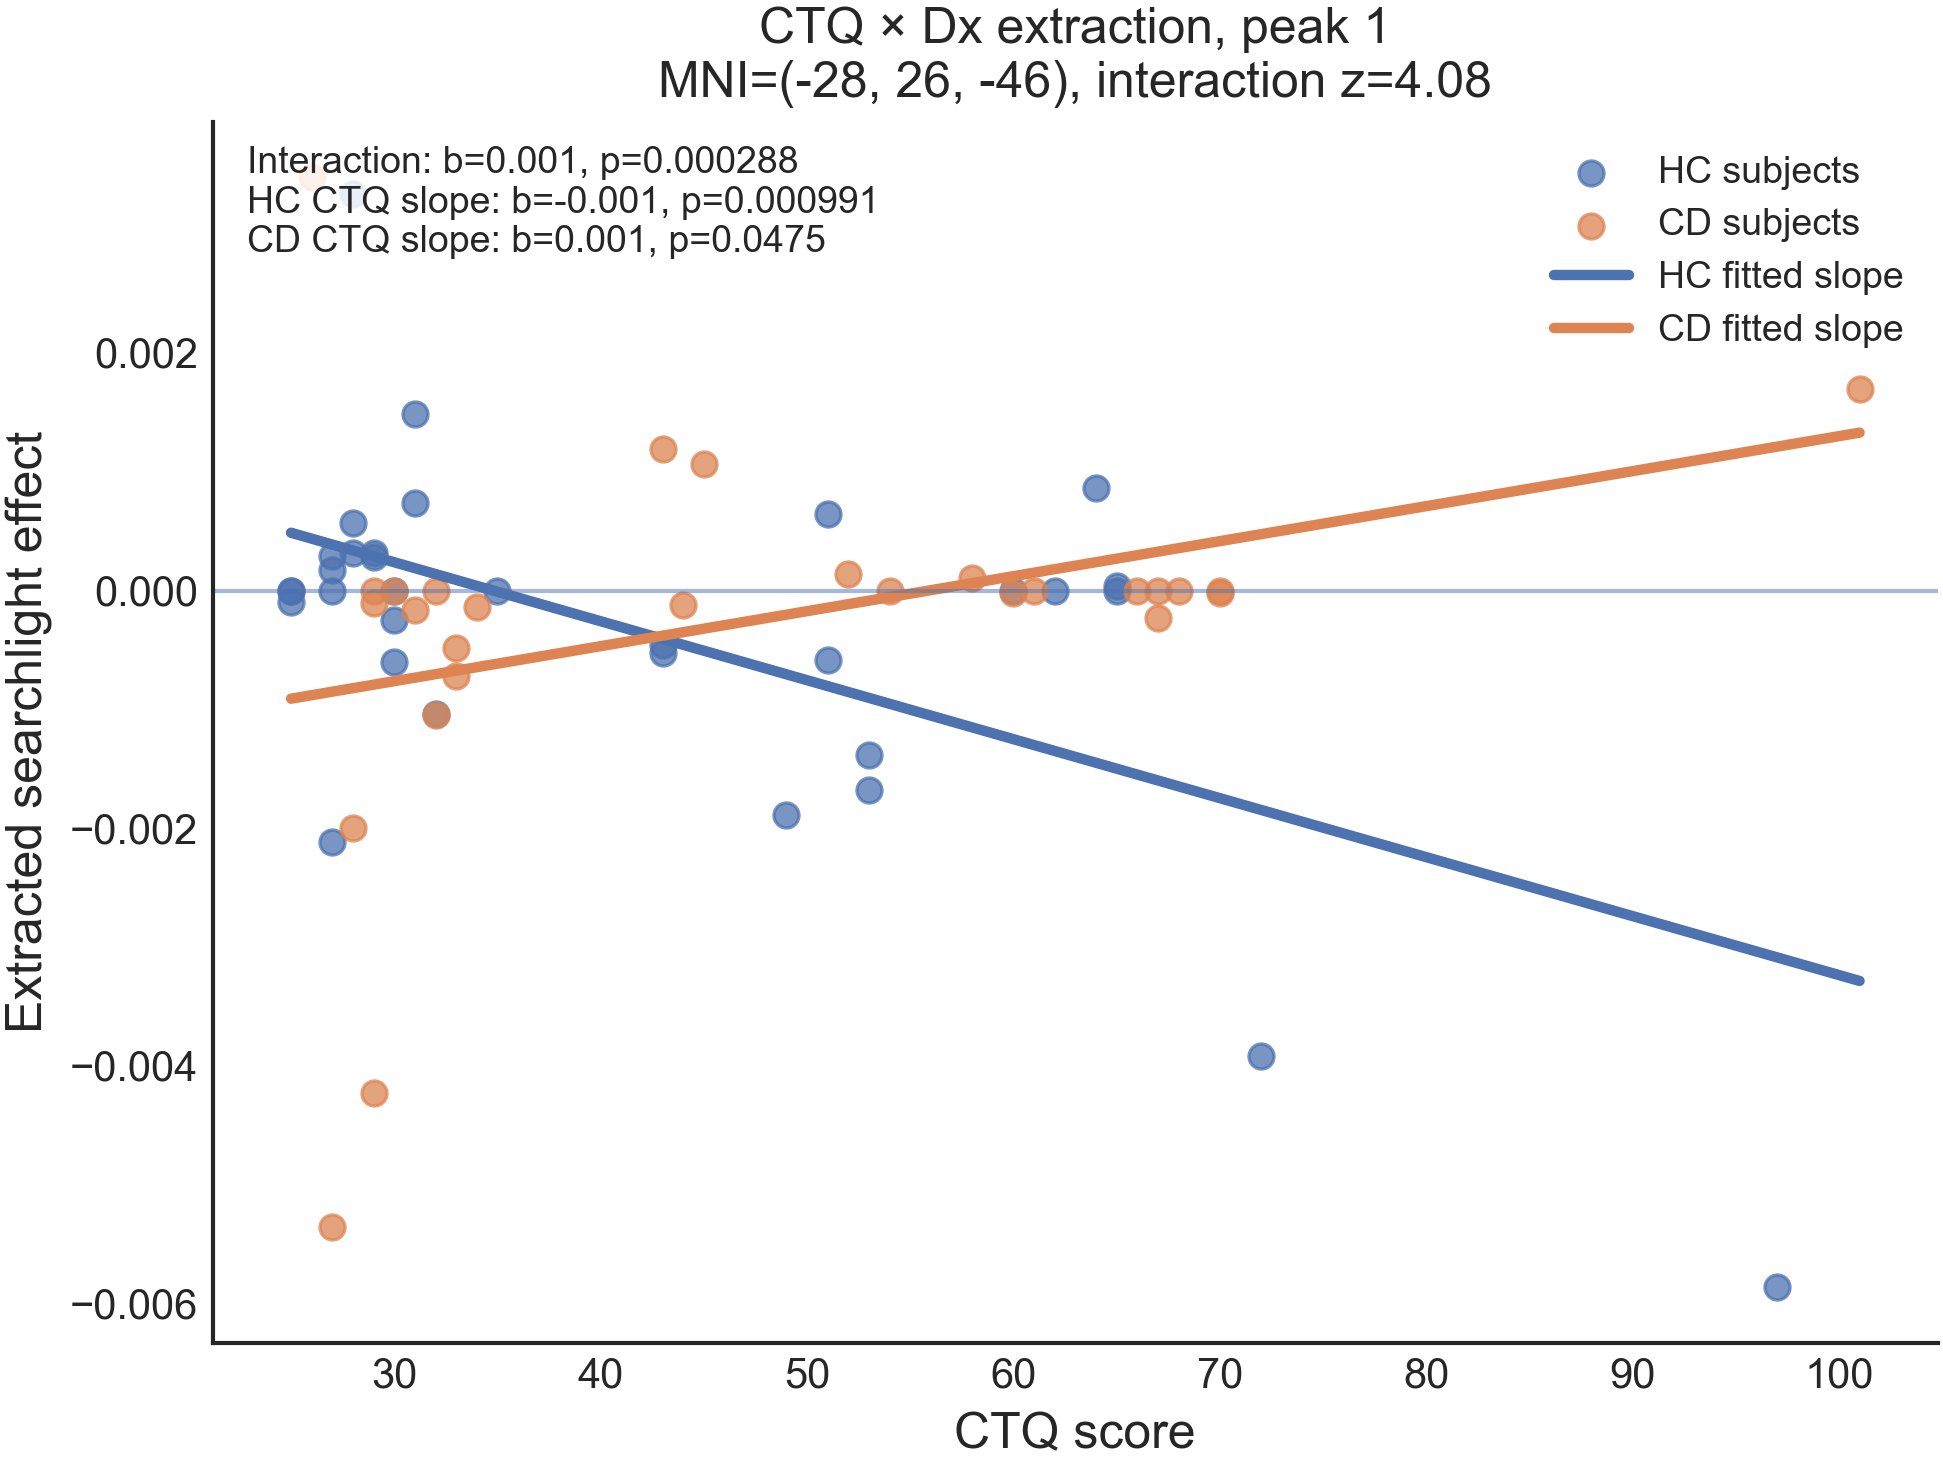

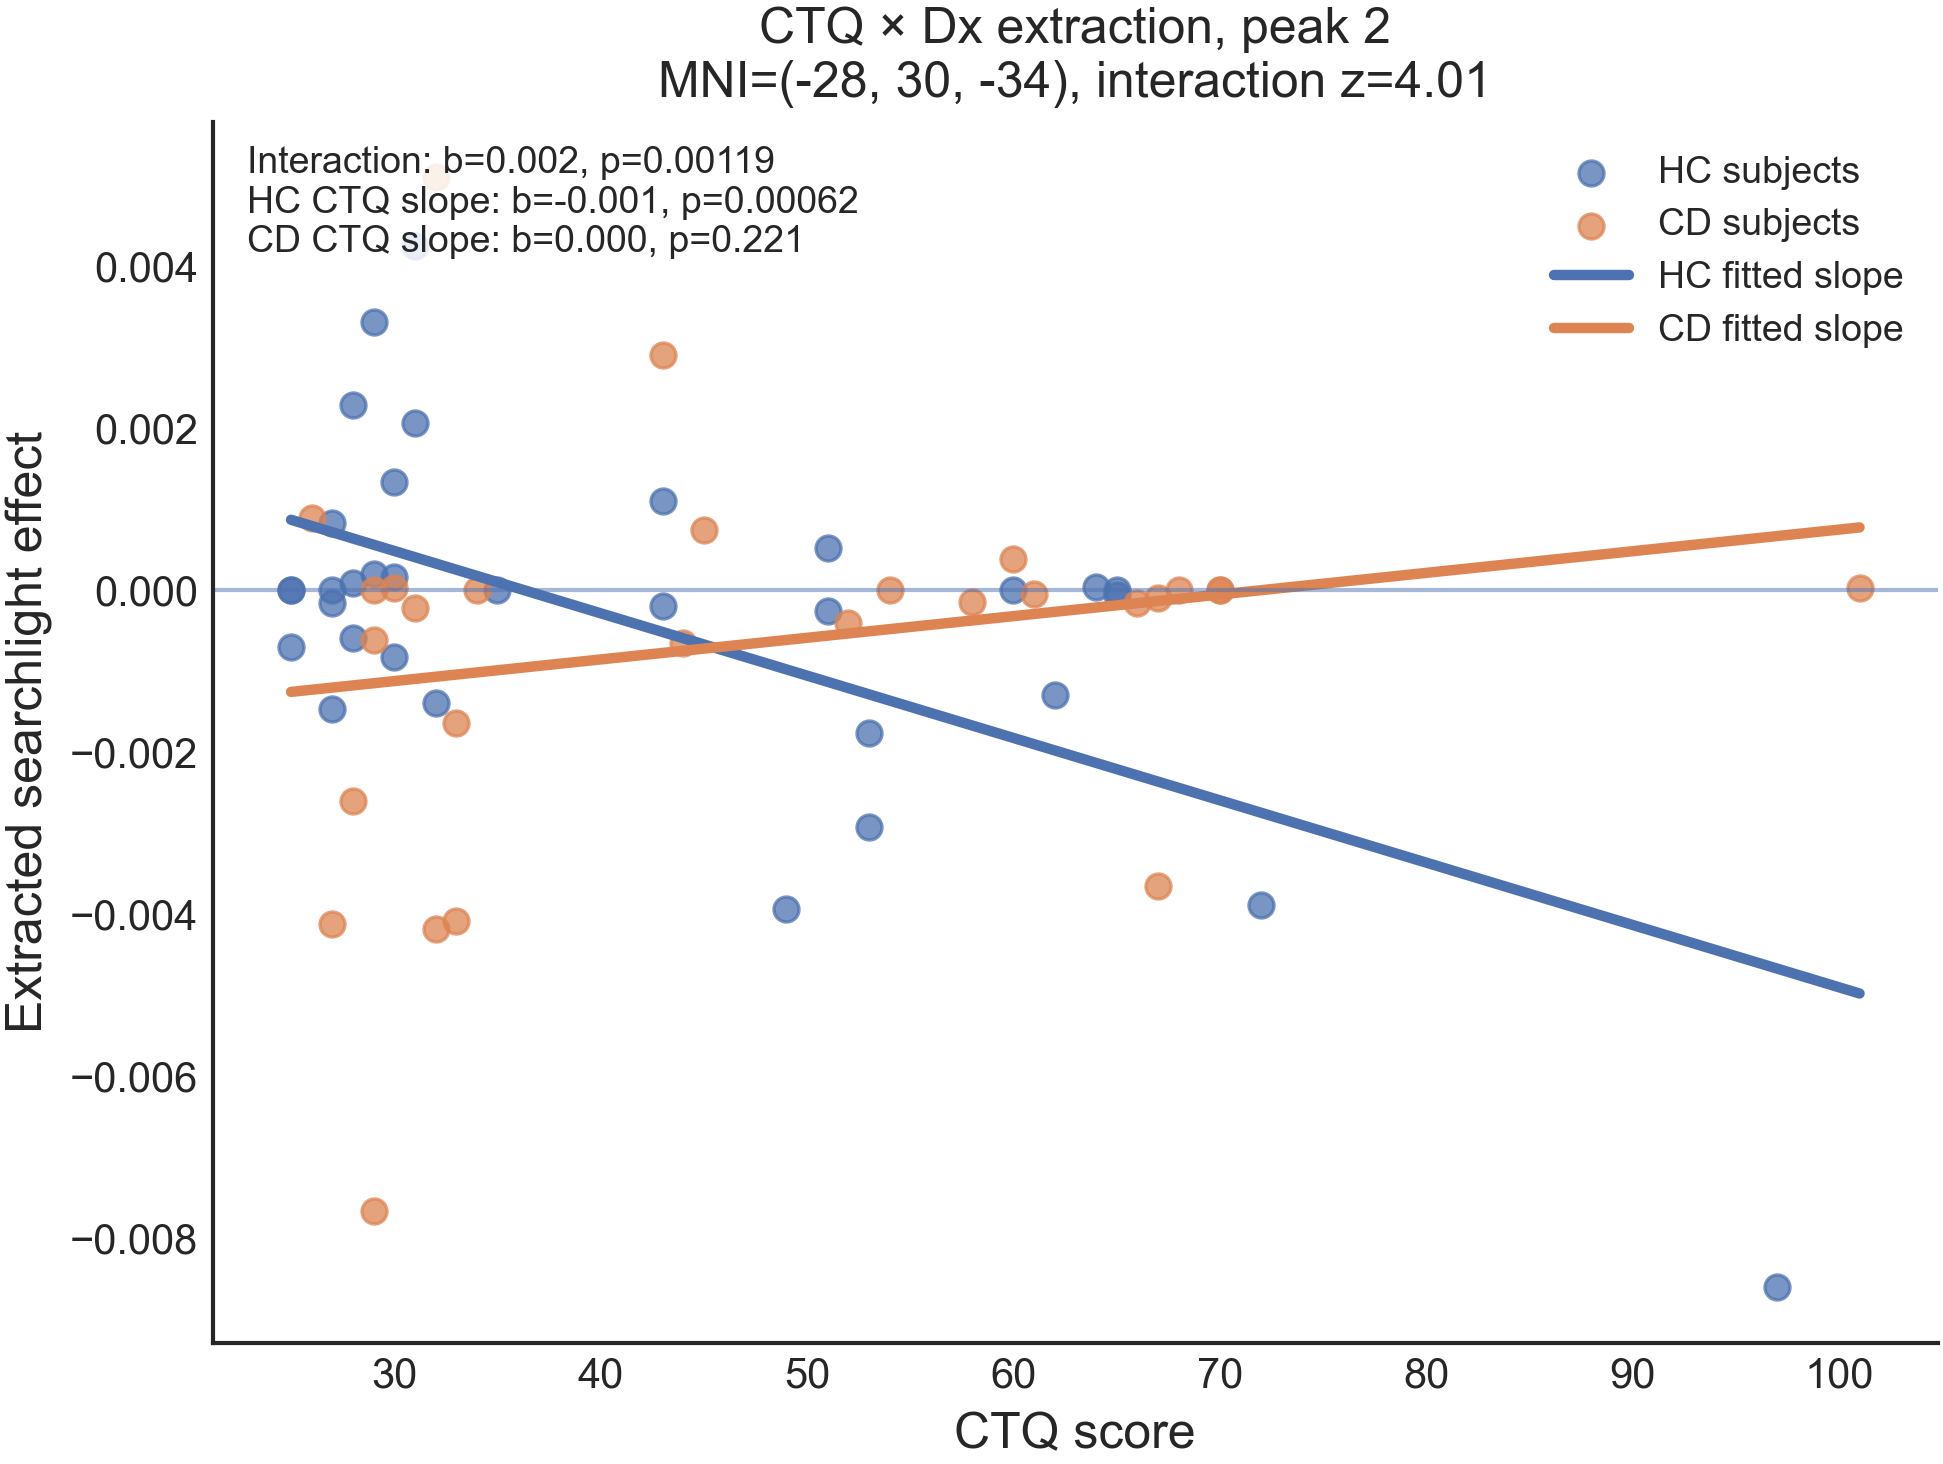

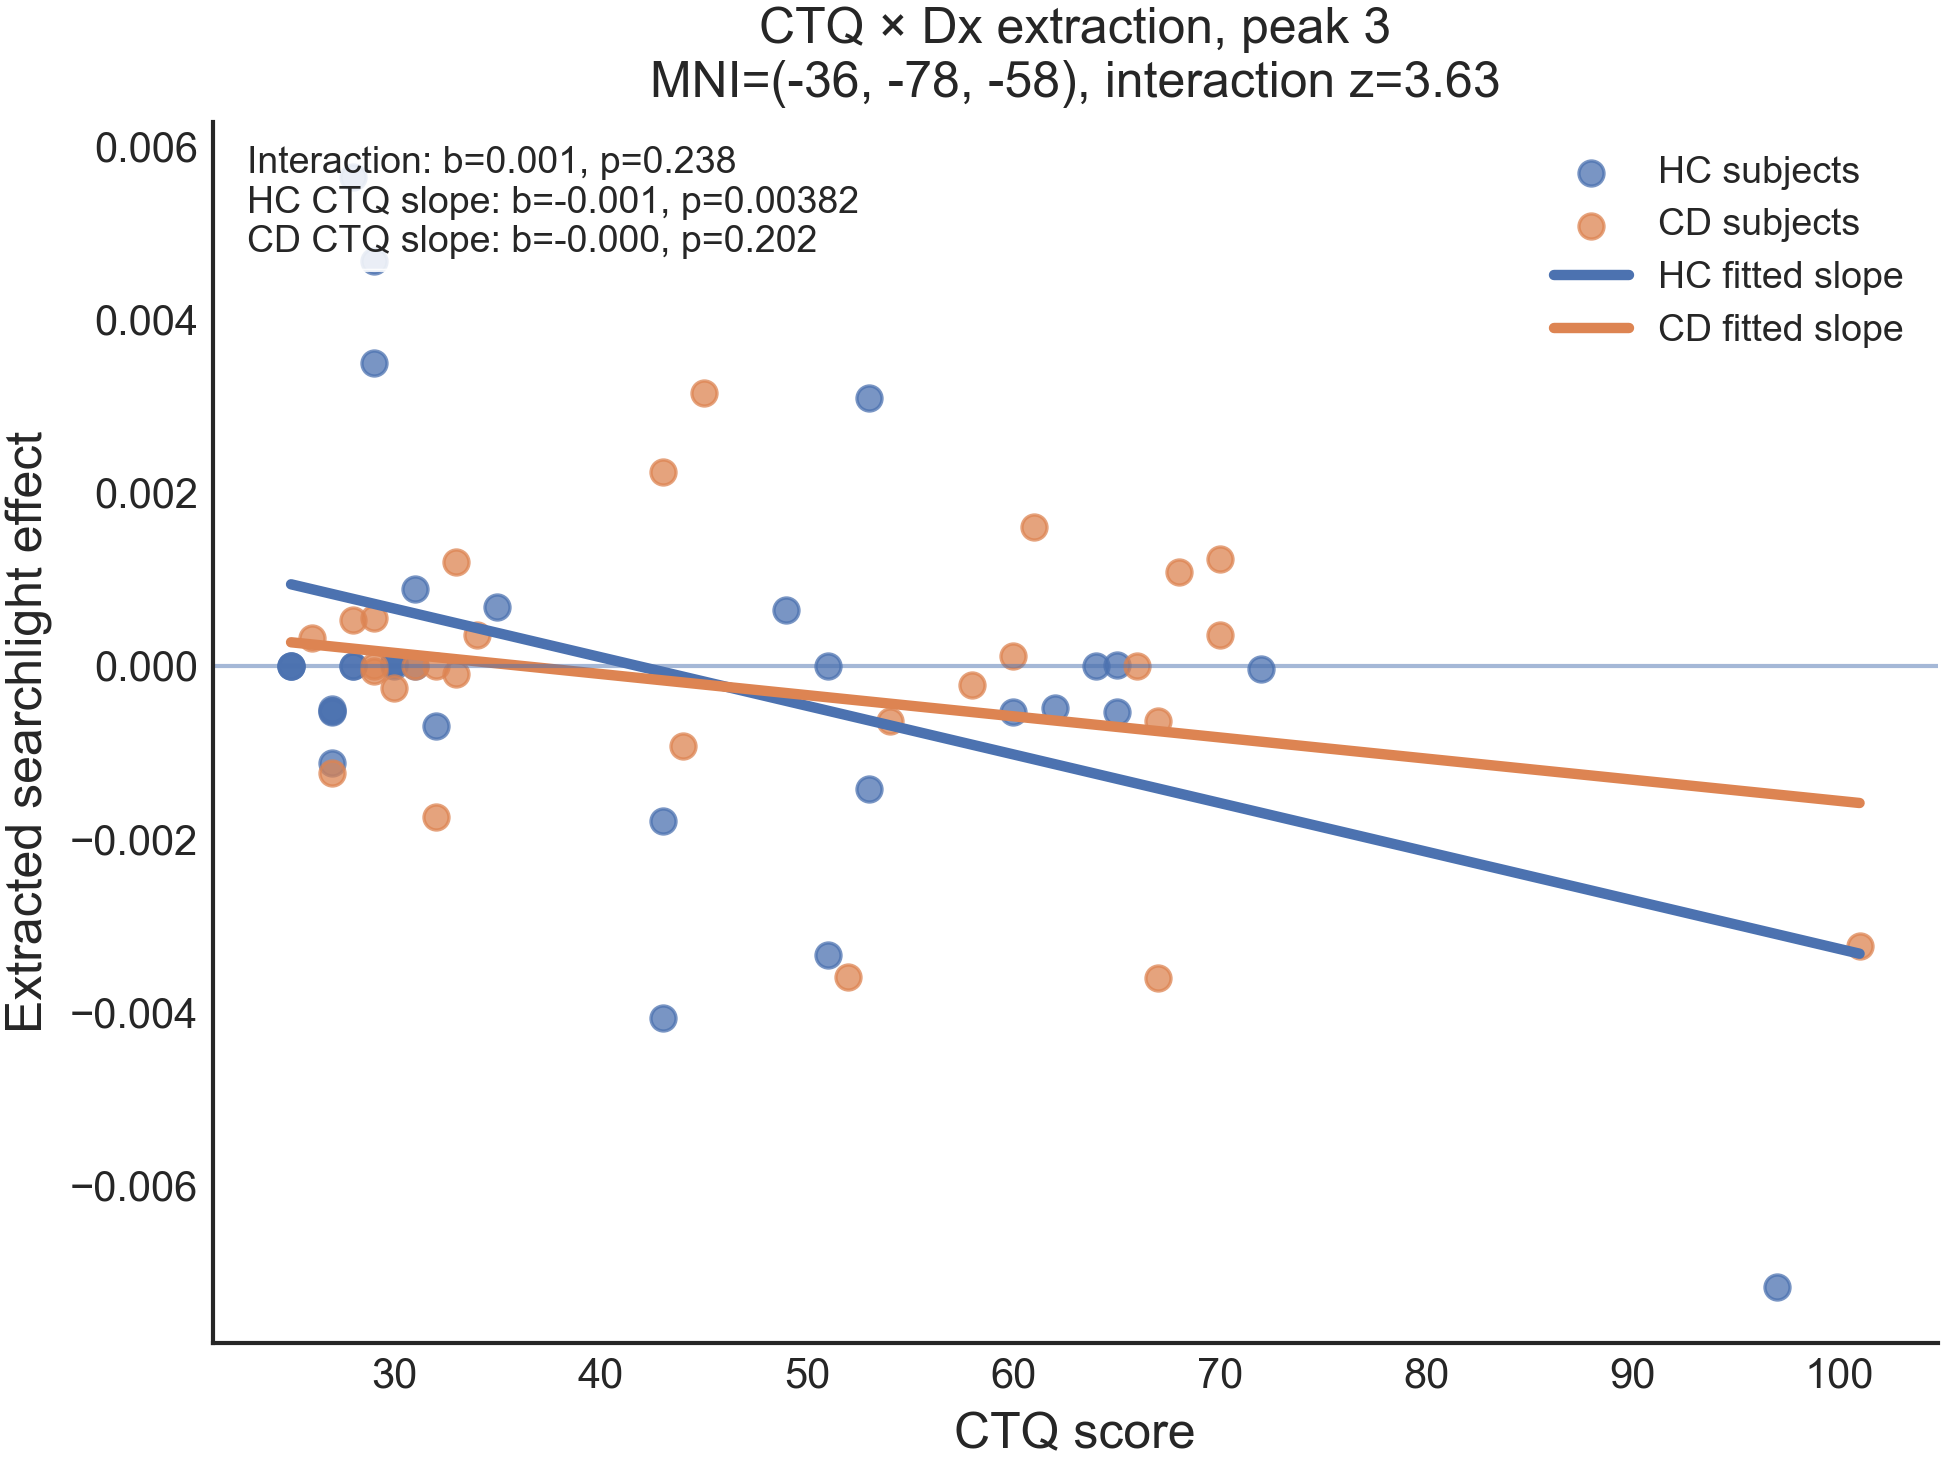

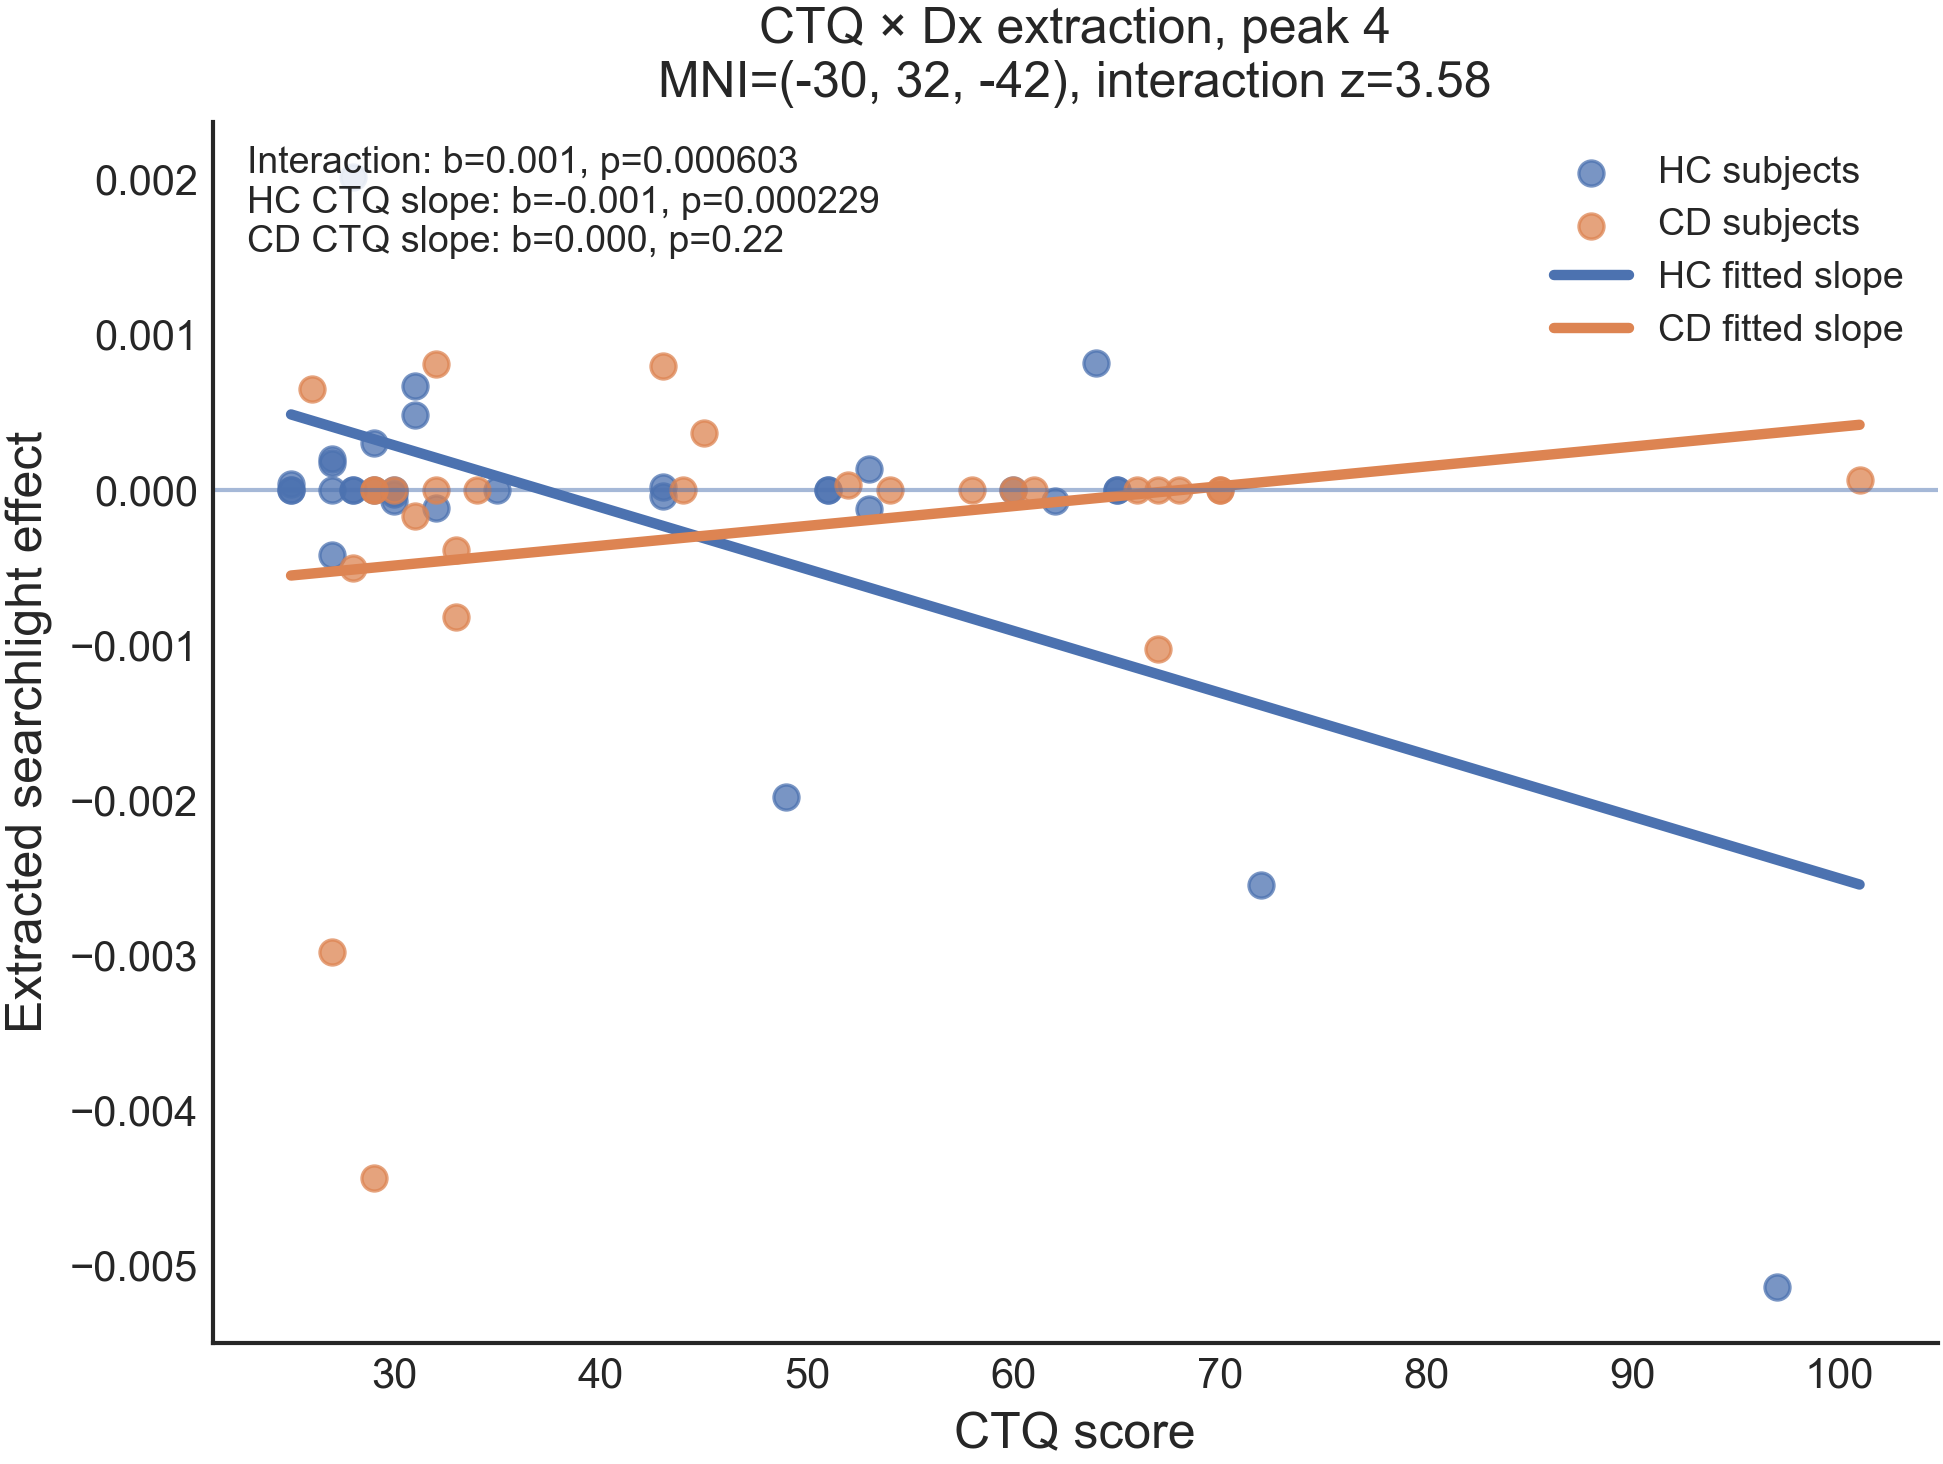

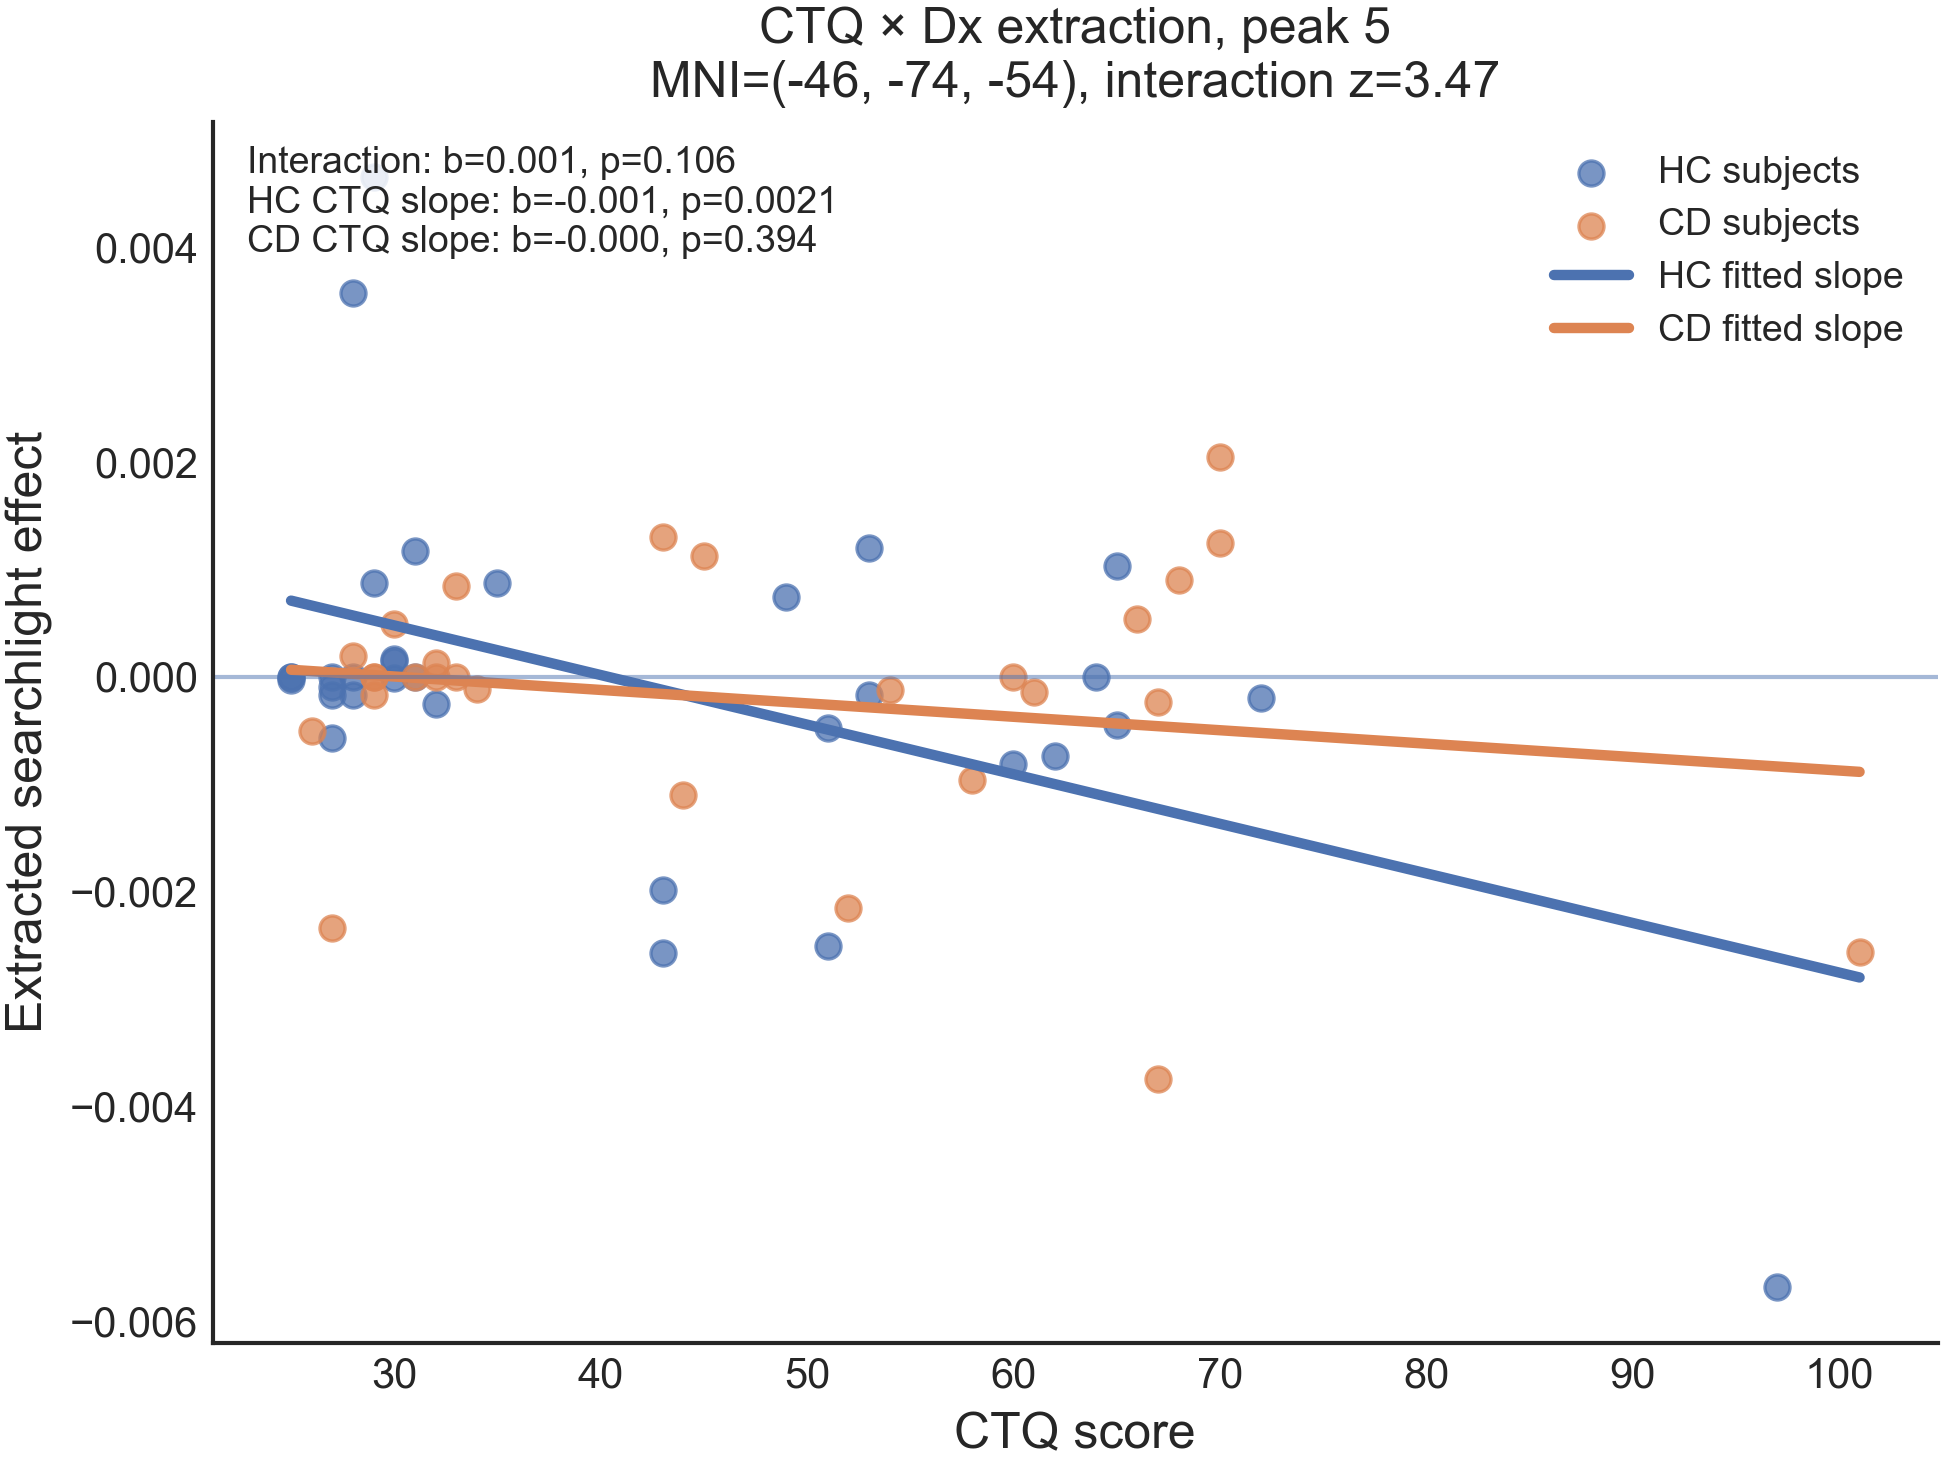

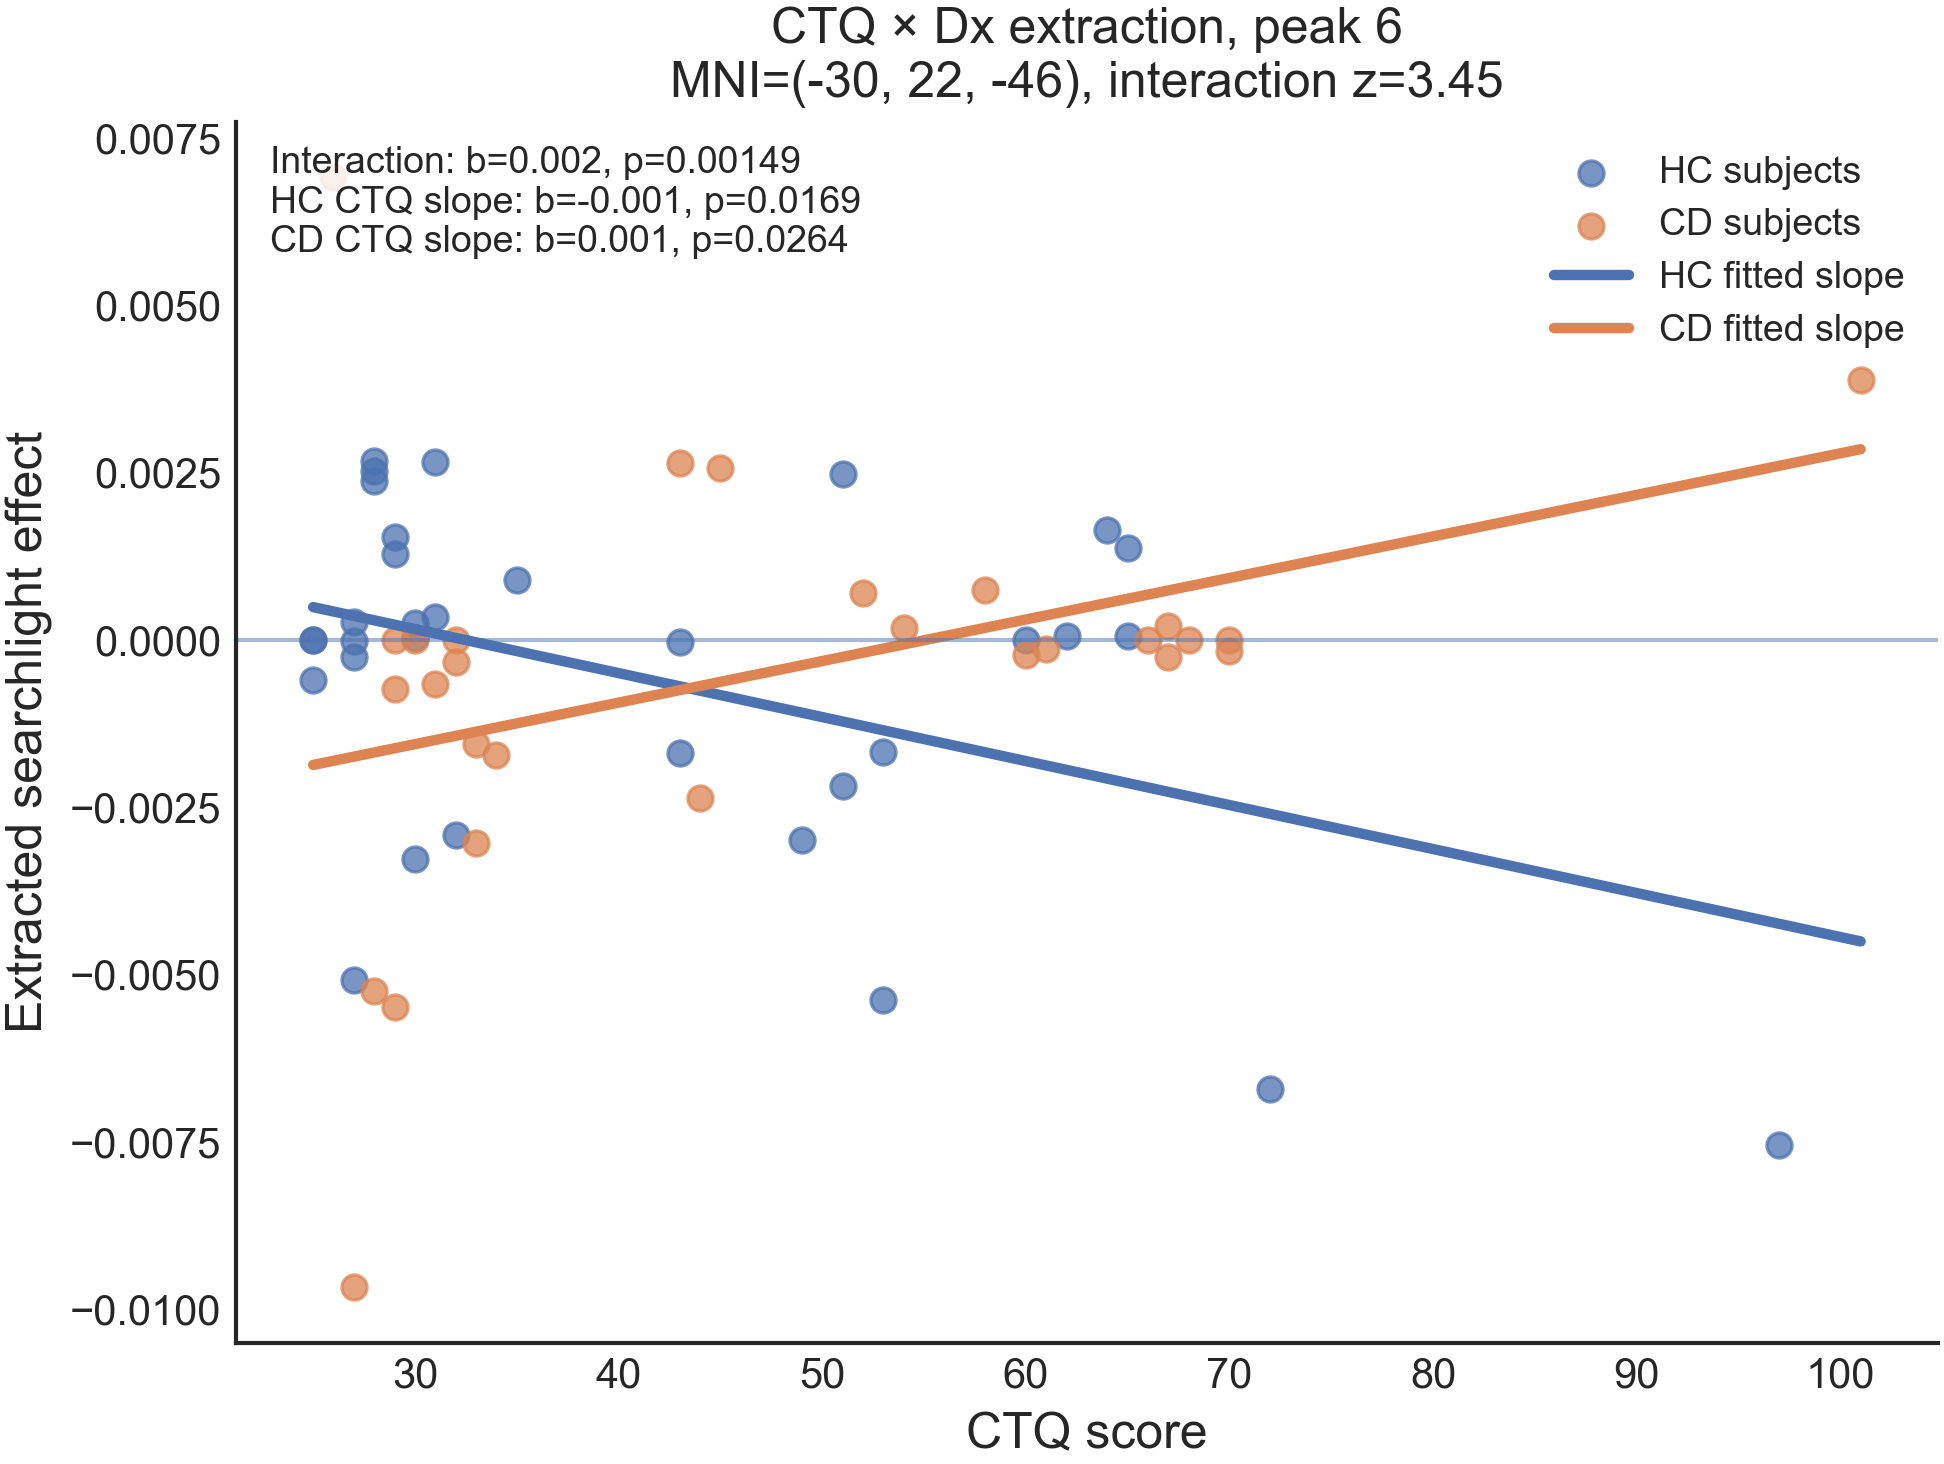

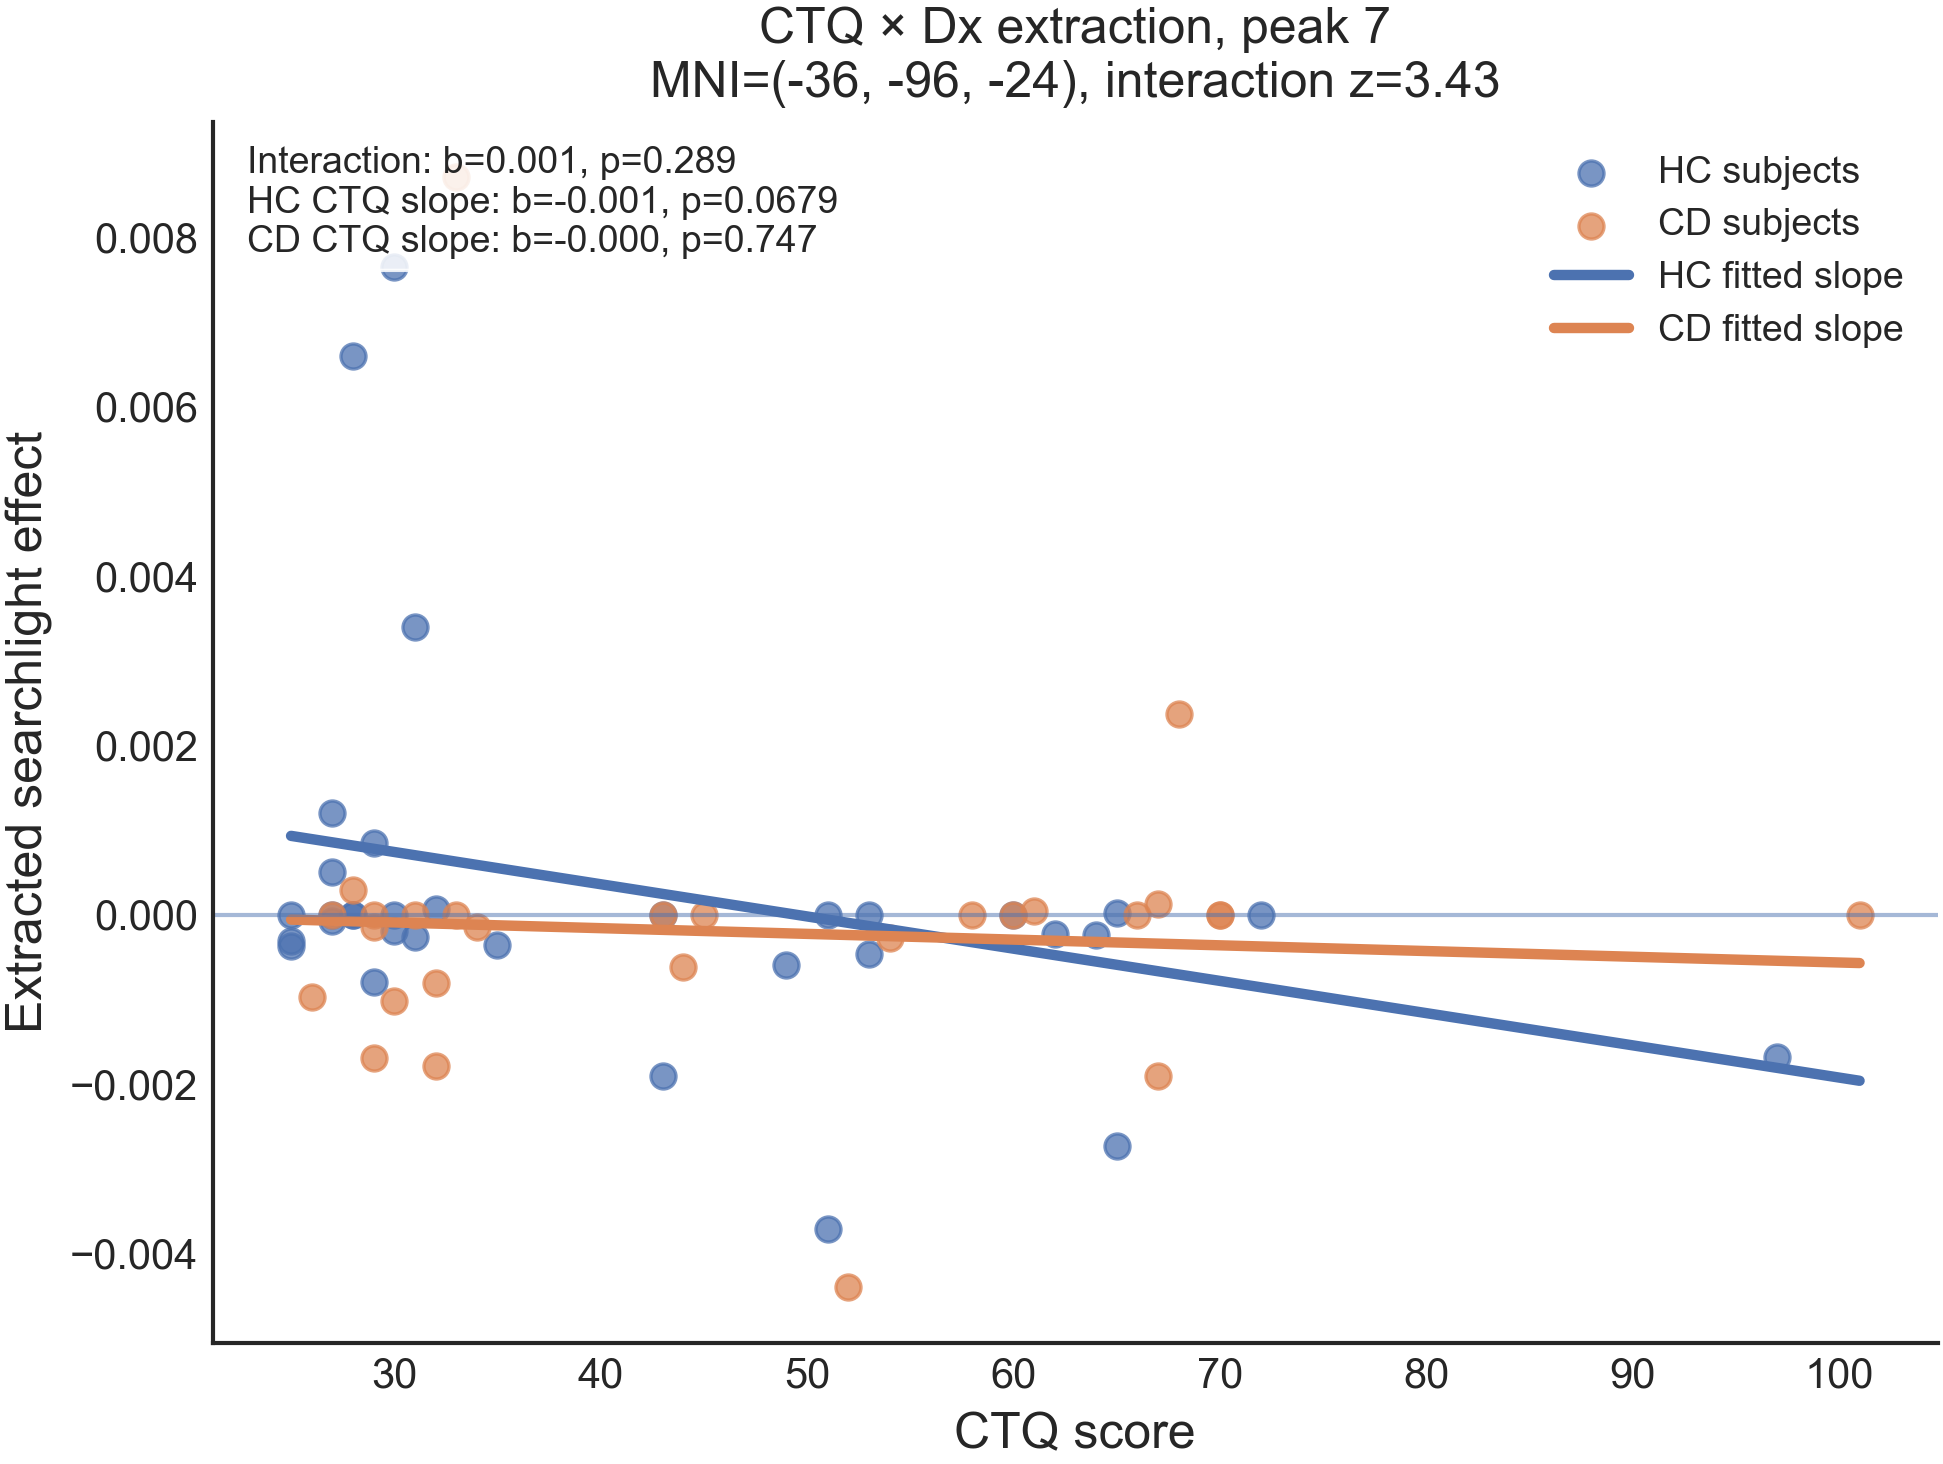

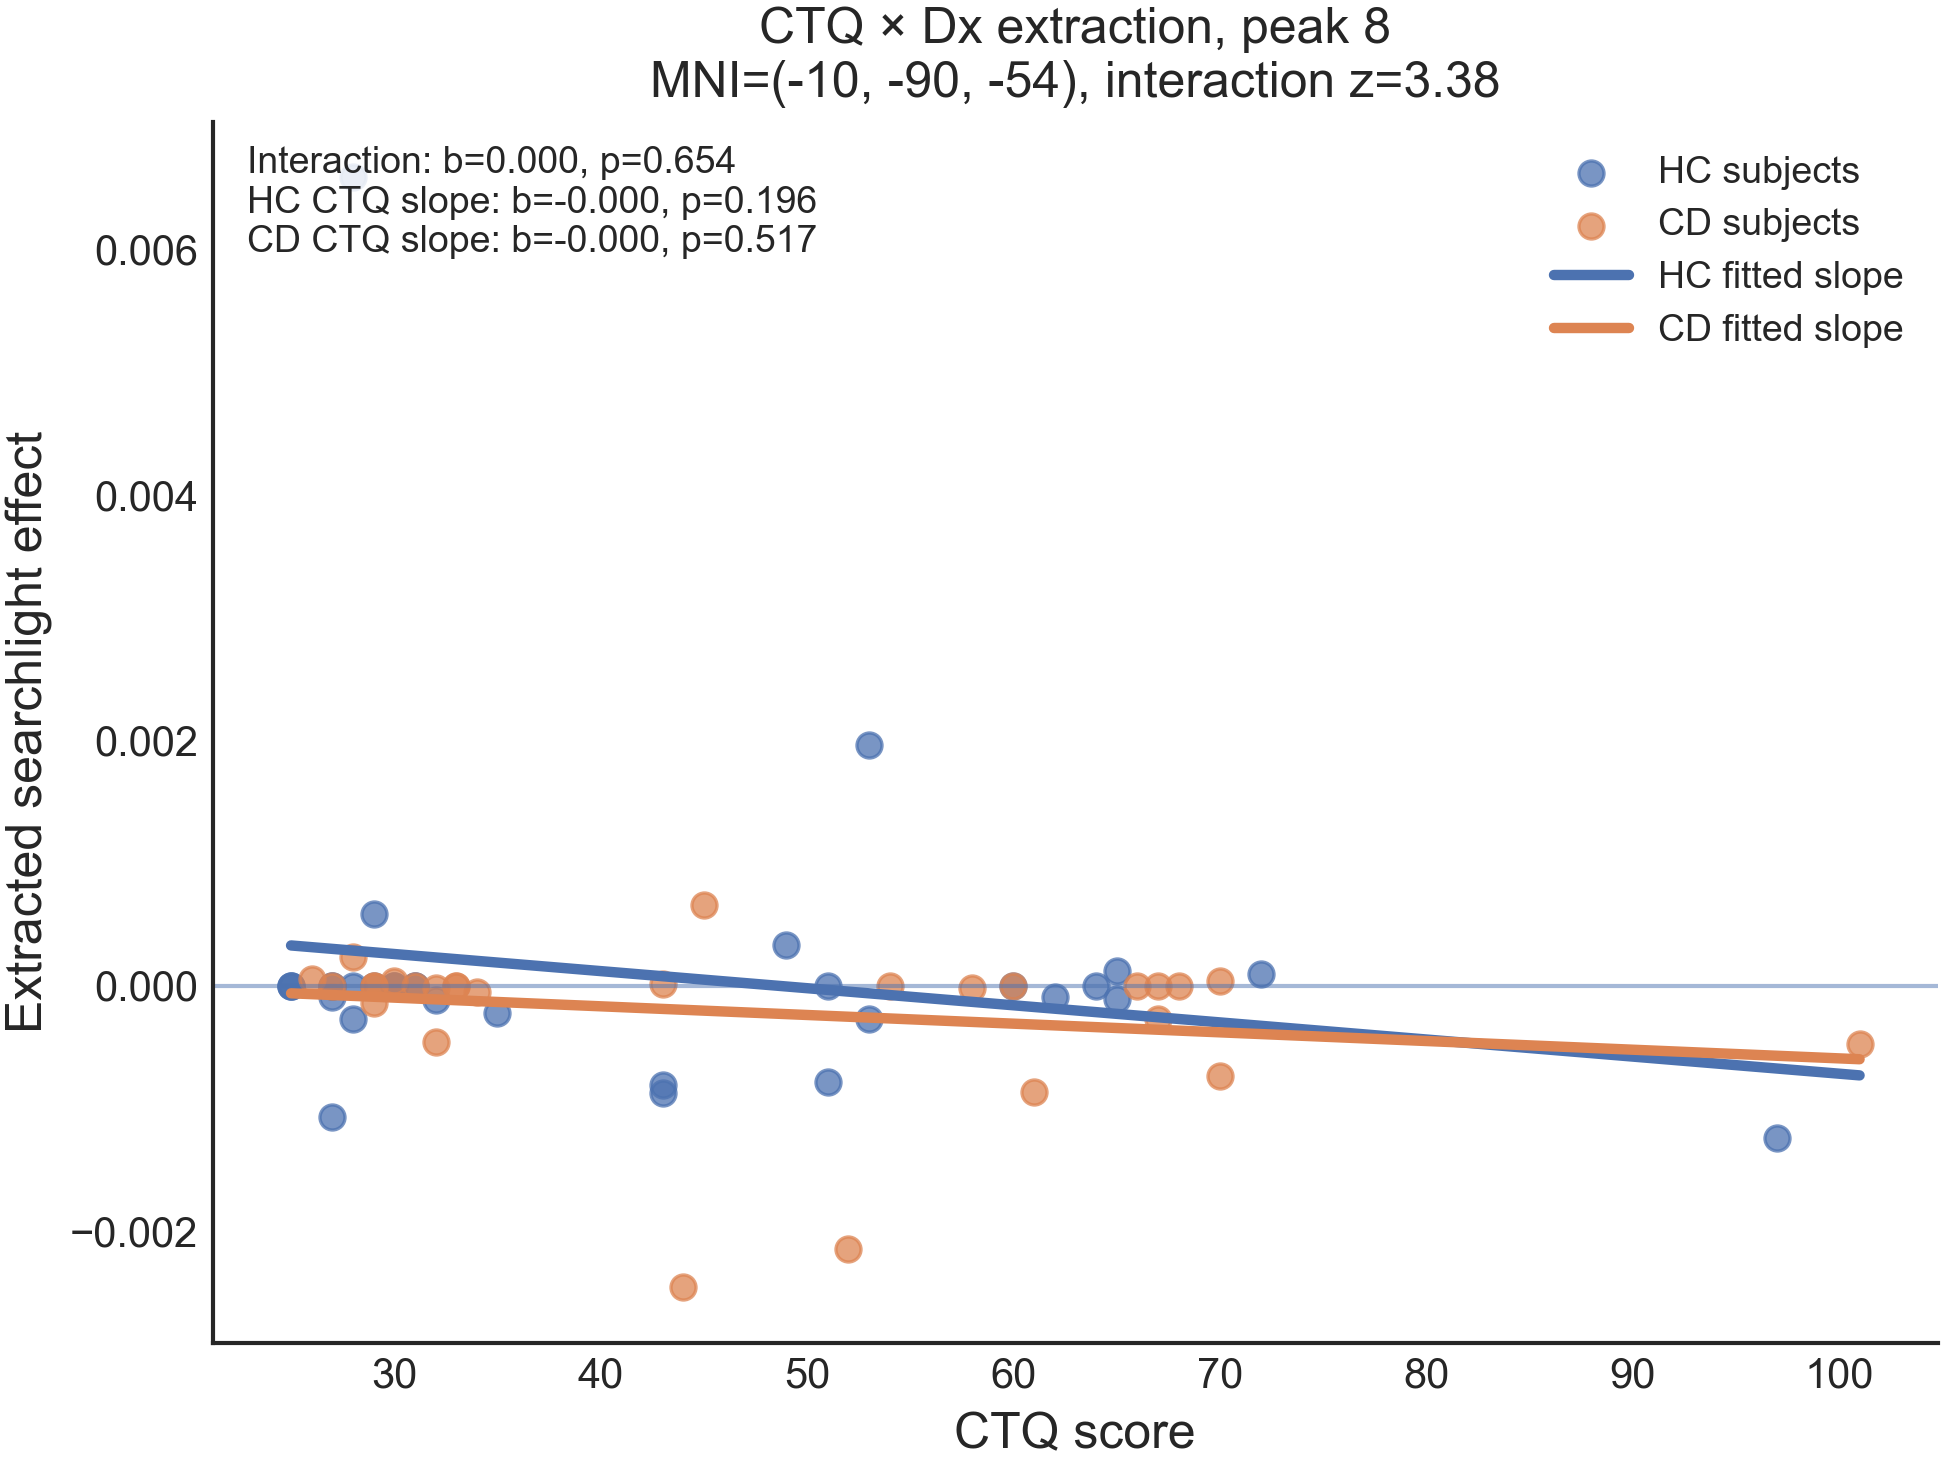


Saved peak model summary: /Users/matty_gee/Desktop/Social/SocialCUD/analyses/lss_decision/statistical-maps/dimension/ctq_interaction_analysis/ctq_x_dx_peak_model_summary.csv


,contrast,estimate,t,p,hypothesis,peak_id,peak_x,peak_y,peak_z,peak_stat,radius_mm
0,ctq_average_slope,-0.000186,-0.993368,0.324961,ctq_score = 0,1,-28.5,25.5,-46.5,4.077114,6
1,ctq_x_dx_slope_difference,0.001462,3.878119,0.000288,dx_x_ctq_score = 0,1,-28.5,25.5,-46.5,4.077114,6
2,ctq_slope_HC,-0.000918,-3.482886,0.000991,ctq_score - 0.5*dx_x_ctq_score = 0,1,-28.5,25.5,-46.5,4.077114,6
3,ctq_slope_CD,0.000545,2.027791,0.047528,ctq_score + 0.5*dx_x_ctq_score = 0,1,-28.5,25.5,-46.5,4.077114,6
4,ctq_average_slope,-0.000464,-1.665532,0.101598,ctq_score = 0,2,-28.5,29.5,-34.5,4.013265,6
5,ctq_x_dx_slope_difference,0.001915,3.422248,0.001191,dx_x_ctq_score = 0,2,-28.5,29.5,-34.5,4.013265,6
6,ctq_slope_HC,-0.001422,-3.635582,0.000620,ctq_score - 0.5*dx_x_ctq_score = 0,2,-28.5,29.5,-34.5,4.013265,6
7,ctq_slope_CD,0.000494,1.238076,0.221044,ctq_score + 0.5*dx_x_ctq_score = 0,2,-28.5,29.5,-34.5,4.013265,6
8,ctq_average_slope,-0.000745,-3.044984,0.003593,ctq_score = 0,3,-36.5,-78.5,-58.5,3.628698,6
9,ctq_x_dx_slope_difference,0.000586,1.193391,0.237933,dx_x_ctq_score = 0,3,-36.5,-78.5,-58.5,3.628698,6



Saved CTQ-family map values at interaction peaks: /Users/matty_gee/Desktop/Social/SocialCUD/analyses/lss_decision/statistical-maps/dimension/ctq_interaction_analysis/ctq_family_map_values_at_interaction_peaks.csv


map,peak_id,peak_x,peak_y,peak_z,interaction_peak_stat,ctq_average_slope,ctq_slope_CD,ctq_slope_HC,ctq_x_dx_slope_difference
0,1,-28.5,25.5,-46.5,4.077114,-0.705562,0.847658,-1.823366,1.872010
1,2,-28.5,29.5,-34.5,4.013265,-1.066950,0.763590,-2.221359,2.092320
2,3,-36.5,-78.5,-58.5,3.628698,-1.541159,-0.291742,-1.848746,1.110981
3,4,-30.5,31.5,-42.5,3.579422,-0.796315,0.406390,-1.495802,1.337418
4,5,-46.5,-74.5,-54.5,3.467440,-1.092392,-0.071612,-1.444859,0.981916
5,6,-30.5,21.5,-46.5,3.449849,-0.279629,1.425553,-1.830506,2.275454
6,7,-36.5,-96.5,-24.5,3.429064,-0.799988,-0.075873,-1.042865,0.688158
7,8,-10.5,-90.5,-54.5,3.382444,-0.875850,-0.115322,-1.090350,0.700110


In [4]:
import statsmodels.formula.api as smf
from pathlib import Path
from nilearn import plotting
from nilearn.image import load_img, math_img
from nilearn.reporting import get_clusters_table
from nilearn.maskers import NiftiSpheresMasker
from IPython.display import display as ipy_display

CTQ_DIR = OUT_DIR / "ctq_interaction_analysis"
CTQ_DIR.mkdir(parents=True, exist_ok=True)
print(f"Saving CTQ interaction analyses to: {CTQ_DIR}")

# ============================================================
# Required maps
# ============================================================

ctq_maps = {
    "ctq_average_slope": OUT_DIR / "ctq_average_slope_zmap_unthresholded.nii.gz",
    "ctq_x_dx_slope_difference": OUT_DIR / "ctq_x_dx_slope_difference_zmap_unthresholded.nii.gz",
    "ctq_slope_HC": OUT_DIR / "ctq_slope_HC_zmap_unthresholded.nii.gz",
    "ctq_slope_CD": OUT_DIR / "ctq_slope_CD_zmap_unthresholded.nii.gz",
}

missing = [name for name, path in ctq_maps.items() if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing expected CTQ maps:\n"
        + "\n".join([f"{name}: {ctq_maps[name]}" for name in missing])
    )

print("\nFound CTQ maps:")
for name, path in ctq_maps.items():
    print(f"  {name}: {path}")

# ============================================================
# 1. Visualize CTQ interaction family
# ============================================================

def save_zmap_views(
    img_path,
    *,
    name,
    thresholds=(0, 1.96, 2.58, 3.29),
    display_mode="ortho",
    cut_coords=None,
):
    """
    Save unthresholded and thresholded cross-cut images plus glass brain.
    """
    img = load_img(str(img_path))

    for thr in thresholds:
        label = str(thr).replace(".", "p")

        display = plotting.plot_stat_map(
            img,
            threshold=thr,
            cmap="RdBu_r",
            symmetric_cbar=True,
            black_bg=False,
            draw_cross=False,
            display_mode=display_mode,
            cut_coords=cut_coords,
            title=f"{name}: |z| > {thr}",
        )

        out_png = CTQ_DIR / f"{name}_crosscuts_zgt_{label}.png"
        display.savefig(str(out_png), dpi=300)
        display.close()

    display = plotting.plot_glass_brain(
        img,
        threshold=2.58,
        colorbar=True,
        plot_abs=False,
        display_mode="lyrz",
        title=f"{name}: glass brain |z| > 2.58",
    )

    out_png = CTQ_DIR / f"{name}_glass_zgt_2p58.png"
    display.savefig(str(out_png), dpi=300)
    display.close()

    view = plotting.view_img(
        img,
        threshold=2.58,
        cmap="RdBu_r",
        symmetric_cmap=True,
        black_bg=False,
        title=f"{name}: interactive |z| > 2.58",
    )

    html_path = CTQ_DIR / f"{name}_interactive_zgt_2p58.html"
    view.save_as_html(str(html_path))

    print(f"Saved views for: {name}")

for name, path in ctq_maps.items():
    save_zmap_views(path, name=name)

# ============================================================
# 2. Cluster tables for CTQ interaction family
# ============================================================

def make_z_cluster_table(
    img_path,
    *,
    name,
    stat_threshold=2.58,
    cluster_threshold=10,
    two_sided=True,
):
    """
    Cluster table for an unthresholded z-map.
    Descriptive unless you are using corrected inference.
    """
    img = load_img(str(img_path))

    table = get_clusters_table(
        img,
        stat_threshold=stat_threshold,
        cluster_threshold=cluster_threshold,
        two_sided=two_sided,
    )

    out_csv = CTQ_DIR / f"{name}_clusters_zgt_{str(stat_threshold).replace('.', 'p')}_k{cluster_threshold}.csv"
    table.to_csv(out_csv, index=False)

    print(f"\n{name}: cluster table")
    if len(table) == 0:
        print("  No clusters at this threshold.")
    else:
        ipy_display(table.head(20))

    print(f"Saved: {out_csv}")

    return table

cluster_tables = {}

for name, path in ctq_maps.items():
    cluster_tables[name] = make_z_cluster_table(
        path,
        name=name,
        stat_threshold=2.58,
        cluster_threshold=10,
        two_sided=True,
    )

# ============================================================
# 3. Optional corrected inference for interaction map
# ============================================================
# This is the main inferential test.
# Turn this on if you want corrected CTQ x Dx inference.

RUN_CTQ_INTERACTION_PERMUTATION = False

if RUN_CTQ_INTERACTION_PERMUTATION:

    print("\nRunning permutation inference for CTQ × Dx interaction...")

    logp_img = run_perm_second_level(
        sl_dict["imgs"],
        dmatrix,
        mask_img=None,
        contrast="dx_x_ctq_score",
        fwhm=0,
        n_perm=5000,
        two_sided=True,
        tfce=False,
        threshold=None,
        random_state=2022,
    )

    logp_path = CTQ_DIR / "ctq_x_dx_slope_difference_logp_FWER.nii.gz"
    nib.save(logp_img, str(logp_path))

    display = plotting.plot_stat_map(
        logp_img,
        threshold=-np.log10(0.05),
        cmap="inferno",
        symmetric_cbar=False,
        black_bg=False,
        draw_cross=False,
        display_mode="ortho",
        cut_coords=None,
        title="CTQ × Dx interaction: -log10 FWER p",
    )

    out_png = CTQ_DIR / "ctq_x_dx_slope_difference_logp_FWER_crosscuts.png"
    display.savefig(str(out_png), dpi=300)
    display.close()

    view = plotting.view_img(
        logp_img,
        threshold=-np.log10(0.05),
        cmap="inferno",
        symmetric_cmap=False,
        black_bg=False,
        title="CTQ × Dx interaction: FWER p < .05",
    )

    html_path = CTQ_DIR / "ctq_x_dx_slope_difference_logp_FWER_interactive.html"
    view.save_as_html(str(html_path))

    print(f"Saved corrected logp map: {logp_path}")
    print(f"Saved corrected visualization: {out_png}")
    print(f"Saved corrected interactive view: {html_path}")

# ============================================================
# 4. Build subject-level dataframe aligned to images
# ============================================================

def make_subject_level_df_from_design(
    *,
    sl_dict,
    dmatrix,
    data,
    sub_col="sub_id",
    raw_cols=("dx", "ctq_score", "sex", "memory_mean", "fd_mean"),
):
    """
    Build subject-level dataframe in image order.

    Includes:
      - image path
      - transformed design columns from dmatrix
      - raw covariates from data, suffixed with _raw
      - dx_label
    """
    sub_ids = [canonical_sub_id(s) for s in sl_dict["sub_ids"]]

    df = data.copy()
    df["_sub_id_canon"] = df[sub_col].apply(canonical_sub_id)

    check_cols = [c for c in raw_cols if c in df.columns]

    nunique = df.groupby("_sub_id_canon")[check_cols].nunique(dropna=False)
    bad = nunique[(nunique > 1).any(axis=1)]

    if len(bad) > 0:
        raise ValueError(
            "Some subjects have multiple different raw covariate values across rows. "
            "Collapse data to one row per subject first.\n"
            f"{bad}"
        )

    df = df.drop_duplicates("_sub_id_canon").set_index("_sub_id_canon")
    df = df.loc[sub_ids].copy()

    out = pd.DataFrame({
        "sub_id": sub_ids,
        "img": sl_dict["imgs"],
    })

    # Add transformed design columns.
    for c in dmatrix.columns:
        out[c] = dmatrix[c].to_numpy()

    # Add raw covariates.
    for c in raw_cols:
        if c in df.columns:
            out[f"{c}_raw"] = df[c].to_numpy()

    # Diagnosis labels.
    if "dx_raw" in out.columns:
        dx_raw = pd.to_numeric(out["dx_raw"], errors="coerce")
        out["dx_label"] = np.where(dx_raw == dx_raw.max(), "CD", "HC")
    else:
        out["dx_label"] = np.where(out["dx"] > 0, "CD", "HC")

    return out

subj_df = make_subject_level_df_from_design(
    sl_dict=sl_dict,
    dmatrix=dmatrix,
    data=data,
    sub_col="sub_id",
    raw_cols=("dx", "ctq_score", "sex", "memory_mean", "fd_mean"),
)

subj_df_path = CTQ_DIR / "subject_level_design_for_ctq_interaction.csv"
subj_df.to_csv(subj_df_path, index=False)
print(f"\nSaved subject-level design: {subj_df_path}")
ipy_display(subj_df.head())

# ============================================================
# 5. Extract values from strongest CTQ × Dx interaction peaks
# Important:
#   Peak-based extraction from the same map is descriptive/circular.
#   Use this to understand direction/driver of the interaction,
#   not as independent confirmation.
# ============================================================

def get_top_peaks_from_cluster_table(
    table,
    *,
    n_peaks=6,
    sort_by_abs=True,
):
    """
    Extract top peak coordinates from nilearn cluster table.
    """
    if table is None or len(table) == 0:
        return pd.DataFrame(columns=["x", "y", "z", "stat"])

    t = table.copy()

    # Robust column names from nilearn cluster table.
    coord_cols = None
    for candidate in [
        ["X", "Y", "Z"],
        ["x", "y", "z"],
    ]:
        if all(c in t.columns for c in candidate):
            coord_cols = candidate
            break

    if coord_cols is None:
        raise ValueError(f"Could not find coordinate columns in table: {t.columns.tolist()}")

    stat_col = None
    for c in ["Peak Stat", "Stat", "peak_stat", "stat"]:
        if c in t.columns:
            stat_col = c
            break

    if stat_col is None:
        raise ValueError(f"Could not find peak stat column in table: {t.columns.tolist()}")

    peaks = t[coord_cols + [stat_col]].copy()
    peaks.columns = ["x", "y", "z", "stat"]

    peaks = peaks.dropna(subset=["x", "y", "z", "stat"]).copy()

    if sort_by_abs:
        peaks["_abs_stat"] = peaks["stat"].abs()
        peaks = peaks.sort_values("_abs_stat", ascending=False)
    else:
        peaks = peaks.sort_values("stat", ascending=False)

    peaks = peaks.head(n_peaks).reset_index(drop=True)

    return peaks[["x", "y", "z", "stat"]]

interaction_table = cluster_tables["ctq_x_dx_slope_difference"]

top_interaction_peaks = get_top_peaks_from_cluster_table(
    interaction_table,
    n_peaks=8,
    sort_by_abs=True,
)

top_interaction_peaks_path = CTQ_DIR / "top_ctq_x_dx_interaction_peaks.csv"
top_interaction_peaks.to_csv(top_interaction_peaks_path, index=False)

print("\nTop CTQ × Dx interaction peaks:")
ipy_display(top_interaction_peaks)
print(f"Saved: {top_interaction_peaks_path}")

def extract_sphere_values(
    imgs,
    coord,
    *,
    radius=6,
):
    """
    Extract mean searchlight value from a sphere around coord.
    """
    coord = tuple(float(x) for x in coord)

    masker = NiftiSpheresMasker(
        seeds=[coord],
        radius=radius,
        standardize=False,
        detrend=False,
    )

    vals = masker.fit_transform(imgs)

    return vals[:, 0]

# Extract values from each top peak.
radius = 6

peak_extract_dfs = []

for i, row in top_interaction_peaks.iterrows():

    coord = (row["x"], row["y"], row["z"])
    stat = row["stat"]

    vals = extract_sphere_values(
        subj_df["img"].tolist(),
        coord,
        radius=radius,
    )

    tmp = subj_df.copy()
    tmp["y"] = vals
    tmp["peak_id"] = i + 1
    tmp["peak_x"] = coord[0]
    tmp["peak_y"] = coord[1]
    tmp["peak_z"] = coord[2]
    tmp["peak_stat"] = stat
    tmp["radius_mm"] = radius

    peak_extract_dfs.append(tmp)

if len(peak_extract_dfs) > 0:
    peak_extract_df = pd.concat(peak_extract_dfs, ignore_index=True)
else:
    peak_extract_df = pd.DataFrame()

peak_extract_path = CTQ_DIR / "ctq_x_dx_peak_sphere_extractions.csv"
peak_extract_df.to_csv(peak_extract_path, index=False)

print(f"\nSaved peak sphere extractions: {peak_extract_path}")

# ============================================================
# 6. Fit and plot extracted interaction effects
# ============================================================

def fit_extracted_interaction_model(df):
    """
    Fit model matching the second-level design, using transformed dmatrix columns.

    y ~ dx + ctq_score + dx_x_ctq_score + sex + memory_mean + fd_mean

    where:
      dx = effect-coded diagnosis
      ctq_score = z-scored CTQ
      dx_x_ctq_score = interaction
    """
    formula_terms = ["dx", "ctq_score", "dx_x_ctq_score"]

    for cov in ["sex", "memory_mean", "fd_mean"]:
        if cov in df.columns:
            formula_terms.append(cov)

    formula = "y ~ " + " + ".join(formula_terms)

    model = smf.ols(formula, data=df).fit()

    tests = {
        "ctq_average_slope": "ctq_score = 0",
        "ctq_x_dx_slope_difference": "dx_x_ctq_score = 0",
        "ctq_slope_HC": "ctq_score - 0.5*dx_x_ctq_score = 0",
        "ctq_slope_CD": "ctq_score + 0.5*dx_x_ctq_score = 0",
    }

    rows = []

    for name, hyp in tests.items():
        tt = model.t_test(hyp)

        rows.append({
            "contrast": name,
            "estimate": float(tt.effect[0]),
            "t": float(tt.tvalue[0][0]),
            "p": float(tt.pvalue),
            "hypothesis": hyp,
        })

    contrast_df = pd.DataFrame(rows)

    return model, contrast_df

def plot_extracted_ctq_interaction(df, *, title, out_png):
    """
    Scatter raw CTQ vs extracted searchlight value by dx group,
    with model-implied simple slopes.
    """
    model, contrast_df = fit_extracted_interaction_model(df)

    fig, ax = plt.subplots(figsize=(6.8, 5.2))

    # Use raw CTQ for x-axis if available.
    if "ctq_score_raw" in df.columns:
        x_raw = pd.to_numeric(df["ctq_score_raw"], errors="coerce").to_numpy()
        x_label = "CTQ score"
        raw_mu = np.nanmean(x_raw)
        raw_sd = np.nanstd(x_raw, ddof=1)
    else:
        x_raw = df["ctq_score"].to_numpy()
        x_label = "CTQ score (z)"
        raw_mu = 0.0
        raw_sd = 1.0

    df = df.copy()
    df["_x_raw_plot"] = x_raw

    # Scatter.
    for lab in ["HC", "CD"]:
        g = df[df["dx_label"].eq(lab)]
        if len(g) == 0:
            continue

        ax.scatter(
            g["_x_raw_plot"],
            g["y"],
            alpha=0.75,
            label=f"{lab} subjects",
        )

    # Model-implied predicted lines.
    x_grid_raw = np.linspace(np.nanmin(x_raw), np.nanmax(x_raw), 100)

    if raw_sd > 0:
        x_grid_z = (x_grid_raw - raw_mu) / raw_sd
    else:
        x_grid_z = x_grid_raw - raw_mu

    pred_base = pd.DataFrame({
        "ctq_score": x_grid_z,
        "sex": 0.0,
        "memory_mean": 0.0,
        "fd_mean": 0.0,
    })

    for lab, dx_value in [("HC", -0.5), ("CD", 0.5)]:
        pred_df = pred_base.copy()
        pred_df["dx"] = dx_value
        pred_df["dx_x_ctq_score"] = pred_df["dx"] * pred_df["ctq_score"]

        # Keep only columns used by the model.
        pred = model.predict(pred_df)

        ax.plot(
            x_grid_raw,
            pred,
            linewidth=2.5,
            label=f"{lab} fitted slope",
        )

    # Annotate key contrast results.
    c = contrast_df.set_index("contrast")

    txt = (
        f"Interaction: b={c.loc['ctq_x_dx_slope_difference', 'estimate']:.3f}, "
        f"p={c.loc['ctq_x_dx_slope_difference', 'p']:.3g}\n"
        f"HC CTQ slope: b={c.loc['ctq_slope_HC', 'estimate']:.3f}, "
        f"p={c.loc['ctq_slope_HC', 'p']:.3g}\n"
        f"CD CTQ slope: b={c.loc['ctq_slope_CD', 'estimate']:.3f}, "
        f"p={c.loc['ctq_slope_CD', 'p']:.3g}"
    )

    ax.text(
        0.02,
        0.98,
        txt,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
    )

    ax.axhline(0, linewidth=1, alpha=0.5)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Extracted searchlight effect")
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=9)
    fig.tight_layout()

    fig.savefig(out_png, dpi=300)
    plt.show()

    return model, contrast_df

# Fit and plot each extracted peak.
peak_model_rows = []

if len(peak_extract_df) > 0:

    for peak_id, df_peak in peak_extract_df.groupby("peak_id"):

        x = df_peak["peak_x"].iloc[0]
        y = df_peak["peak_y"].iloc[0]
        z = df_peak["peak_z"].iloc[0]
        stat = df_peak["peak_stat"].iloc[0]

        title = (
            f"CTQ × Dx extraction, peak {peak_id}\n"
            f"MNI=({x:.0f}, {y:.0f}, {z:.0f}), interaction z={stat:.2f}"
        )

        out_png = CTQ_DIR / f"peak_{int(peak_id):02d}_ctq_x_dx_extraction_plot.png"

        model, contrast_df = plot_extracted_ctq_interaction(
            df_peak,
            title=title,
            out_png=out_png,
        )

        contrast_df = contrast_df.copy()
        contrast_df["peak_id"] = peak_id
        contrast_df["peak_x"] = x
        contrast_df["peak_y"] = y
        contrast_df["peak_z"] = z
        contrast_df["peak_stat"] = stat
        contrast_df["radius_mm"] = radius

        peak_model_rows.append(contrast_df)

if len(peak_model_rows) > 0:
    peak_model_summary = pd.concat(peak_model_rows, ignore_index=True)
else:
    peak_model_summary = pd.DataFrame()

peak_model_summary_path = CTQ_DIR / "ctq_x_dx_peak_model_summary.csv"
peak_model_summary.to_csv(peak_model_summary_path, index=False)

print(f"\nSaved peak model summary: {peak_model_summary_path}")
ipy_display(peak_model_summary)

# ============================================================
# 7. Compare map signs: is interaction driven by HC or CD slope?
# ============================================================

def summarize_map_values_at_interaction_peaks(
    peaks,
    maps,
    *,
    radius=6,
):
    """
    For each interaction peak, extract the value from each CTQ-family z-map.
    This tells you whether interaction peaks coincide with HC/CD simple slope effects.
    """
    rows = []

    for i, row in peaks.iterrows():

        coord = (row["x"], row["y"], row["z"])

        for map_name, map_path in maps.items():

            vals = extract_sphere_values(
                [str(map_path)],
                coord,
                radius=radius,
            )

            rows.append({
                "peak_id": i + 1,
                "peak_x": coord[0],
                "peak_y": coord[1],
                "peak_z": coord[2],
                "interaction_peak_stat": row["stat"],
                "map": map_name,
                "sphere_mean_z": float(vals[0]),
                "radius_mm": radius,
            })

    return pd.DataFrame(rows)

if len(top_interaction_peaks) > 0:

    peak_map_summary = summarize_map_values_at_interaction_peaks(
        top_interaction_peaks,
        ctq_maps,
        radius=radius,
    )

    peak_map_summary_path = CTQ_DIR / "ctq_family_map_values_at_interaction_peaks.csv"
    peak_map_summary.to_csv(peak_map_summary_path, index=False)

    print(f"\nSaved CTQ-family map values at interaction peaks: {peak_map_summary_path}")
    display(peak_map_summary.pivot_table(
        index=["peak_id", "peak_x", "peak_y", "peak_z", "interaction_peak_stat"],
        columns="map",
        values="sphere_mean_z",
    ).reset_index())

# ============================================================
# 8. Optional ROI-level CTQ × Dx analysis
# ============================================================

# ROI_MASKS = {
#     "PCC": "/path/to/pcc_mask.nii.gz",
#     "HPC_L": "/path/to/HPC-L_harvardoxford_maxprob-thr25_1mm.nii.gz",
#     "HPC_bilat": "/path/to/HPC-bilat_harvardoxford_maxprob-thr25_1mm.nii.gz",
# }
#
# Then set RUN_ROI_ANALYSIS = True.

RUN_ROI_ANALYSIS = False

ROI_MASKS = {
    # "PCC": "/path/to/pcc_mask.nii.gz",
    # "HPC_L": "/path/to/HPC-L_harvardoxford_maxprob-thr25_1mm.nii.gz",
    # "HPC_bilat": "/path/to/HPC-bilat_harvardoxford_maxprob-thr25_1mm.nii.gz",
}

if RUN_ROI_ANALYSIS:

    from nilearn.maskers import NiftiMasker

    roi_rows = []
    roi_model_rows = []

    for roi_name, roi_path in ROI_MASKS.items():

        print(f"\nExtracting ROI: {roi_name}")

        masker = NiftiMasker(
            mask_img=str(roi_path),
            standardize=False,
            detrend=False,
        )

        vals = masker.fit_transform(subj_df["img"].tolist()).mean(axis=1)

        roi_df = subj_df.copy()
        roi_df["roi"] = roi_name
        roi_df["y"] = vals

        model, contrast_df = fit_extracted_interaction_model(roi_df)

        contrast_df = contrast_df.copy()
        contrast_df["roi"] = roi_name

        roi_rows.append(roi_df)
        roi_model_rows.append(contrast_df)

        out_png = CTQ_DIR / f"roi_{roi_name}_ctq_x_dx_plot.png"

        plot_extracted_ctq_interaction(
            roi_df,
            title=f"ROI: {roi_name}",
            out_png=out_png,
        )

    roi_extract_df = pd.concat(roi_rows, ignore_index=True)
    roi_summary_df = pd.concat(roi_model_rows, ignore_index=True)

    roi_extract_path = CTQ_DIR / "roi_ctq_x_dx_extractions.csv"
    roi_summary_path = CTQ_DIR / "roi_ctq_x_dx_model_summary.csv"

    roi_extract_df.to_csv(roi_extract_path, index=False)
    roi_summary_df.to_csv(roi_summary_path, index=False)

    print(f"Saved ROI extractions: {roi_extract_path}")
    print(f"Saved ROI summary: {roi_summary_path}")

    ipy_display(roi_summary_df)

# previous

In [ ]:
def parse_sub_id(path: str) -> str:
    """Extract sub_id from a path like .../sub-01_foo.nii.gz or .../sub-123_foo.nii.gz."""
    fname = Path(path).name
    return fname.split("_")[0].replace("sub-", "")

def find_sl_imgs(sl_dir: str, sl_fname_pattern: str, incl_subs: set[str] | None = None) -> dict:
    """
    Find searchlight images matching pattern, optionally filter by incl_subs.

    Returns dict with:
      - sub_ids
      - imgs
    """
    sl_dir = str(sl_dir)
    paths = sorted(glob.glob(os.path.join(sl_dir, f"*{sl_fname_pattern}*")))

    if incl_subs is not None:
        paths = [p for p in paths if parse_sub_id(p) in incl_subs]

    sub_ids = [parse_sub_id(p) for p in paths]

    print(f"[find_sl_imgs] Found {len(paths)} images")
    return {
        "sub_ids": sub_ids,
        "imgs": paths,
    }

def build_design_matrix_simple(
    sub_ids: list[str],
    covariates: list[str] | None = None,
    *,
    data: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """
    Build a second-level design matrix with:
      - intercept
      - optional covariates

    Covariates:
      - "reaction_time": computed internally as |mean RT_affil − mean RT_power|
                         using load_behavior(sub_id, neutrals=False) and responded trials.
      - other covariates: looked up in `data` by sub_id

    Notes:
      - Include intercept explicitly; use model_intercept=False in nilearn.
      - Covariates are z-scored across all included subjects.
    """
    covariates = covariates or []
    sub_ids = list(sub_ids)

    def _reaction_time_diff(sub_id: str) -> float:
        try:
            behav = load_behavior(sub_id, neutrals=False)  # must exist in your namespace
        except NameError as e:
            raise NameError(
                "Covariate 'reaction_time' requested, but load_behavior(...) is not defined "
                "in the current namespace."
            ) from e

        behav = behav.loc[behav["responded"]]
        m = behav.groupby("dimension")["reaction_time"].mean()
        return float(abs(m.get("affil", np.nan) - m.get("power", np.nan)))

    def _lookup_cov(sub_id: str, cov: str) -> float:
        if data is None:
            raise ValueError(f"covariate='{cov}' requested but `data` was not provided.")
        if "sub_id" not in data.columns or cov not in data.columns:
            raise ValueError(f"`data` must include columns: sub_id and {cov}")

        _data = data
        if _data["sub_id"].dtype != object:
            _data = _data.copy()
            _data["sub_id"] = _data["sub_id"].astype(str)

        lookup = _data.set_index("sub_id")[cov]
        return float(lookup.loc[sub_id])

    dm = pd.DataFrame(index=np.arange(len(sub_ids)))
    dm["intercept"] = 1.0

    for cov in covariates:
        if cov == "reaction_time":
            vals = np.array([_reaction_time_diff(sid) for sid in sub_ids], dtype=float)
        else:
            vals = np.array([_lookup_cov(sid, cov) for sid in sub_ids], dtype=float)

        mu = np.nanmean(vals)
        sd = np.nanstd(vals, ddof=1)
        vals = (vals - mu) / sd if np.isfinite(sd) and sd > 0 else (vals - mu)

        if np.isnan(vals).any():
            bad = [sub_ids[i] for i in np.where(np.isnan(vals))[0]]
            raise ValueError(f"NaNs in covariate '{cov}' for sub_ids: {bad}")

        dm[cov] = vals

    return dm

def _coerce_to_logp_img(npi_out):
    """Return a Nifti1Image of -log10(p_FWER) from nilearn non_parametric_inference output."""
    if isinstance(npi_out, nib.Nifti1Image):
        return npi_out

    if isinstance(npi_out, dict):
        for k in ["logp_max_t", "logp_max_mass", "logp_max_tfce"]:
            if k in npi_out and isinstance(npi_out[k], nib.Nifti1Image):
                return npi_out[k]
        for v in npi_out.values():
            if isinstance(v, nib.Nifti1Image):
                return v

    raise TypeError(f"Cannot coerce non_parametric_inference output type: {type(npi_out)}")

def make_contrast_vector(
    design_matrix: pd.DataFrame,
    contrast: str = "intercept",
    tail: str | None = "greater",
) -> np.ndarray:
    cols = list(design_matrix.columns)
    if contrast not in cols:
        raise ValueError(f"Contrast '{contrast}' not found in design matrix columns: {cols}")

    v = np.zeros(len(cols), dtype=float)
    v[cols.index(contrast)] = 1.0

    if tail is None or tail == "greater":
        return v
    elif tail == "less":
        return -v
    else:
        raise ValueError("tail must be None, 'greater', or 'less'")
    
def run_perm_second_level(
    imgs: list[str],
    design_matrix: pd.DataFrame,
    *,
    mask_img,
    contrast_vec: np.ndarray,
    fwhm: float | None = 8.0,
    n_perm: int = 5000,
    two_sided: bool = False,
    tfce: bool = False,
    threshold=None,
    random_state: int = 2022,
):
    """
    Runs nilearn's permutation inference (max-type correction)
    and returns a -log10(p_FWER) image.
    """
    out = non_parametric_inference(
        imgs,
        design_matrix=design_matrix,
        second_level_contrast=contrast_vec,
        mask=mask_img,
        smoothing_fwhm=fwhm,
        n_perm=n_perm,
        two_sided_test=two_sided,
        tfce=tfce,
        threshold=threshold,
        model_intercept=False,   # because design_matrix includes intercept explicitly
        random_state=random_state,
        n_jobs=-1,
        verbose=1,
    )
    return _coerce_to_logp_img(out)

def run_parametric_second_level(
    imgs: list[str],
    design_matrix: pd.DataFrame,
    *,
    mask_img,
    contrast_vec: np.ndarray | None = None,
    contrast: str | None = None,
    fwhm: float | None = 8.0,
    output_type: str = "z_score",
):
    """
    Standard parametric second-level GLM using nilearn.

    Returns
    -------
    out_img : nib.Nifti1Image
        Image ready to plot. Default is a z-stat map.
        Other useful output_type values: "stat", "p_value", "effect_size", "effect_variance".
    """
    if (contrast_vec is None) == (contrast is None):
        raise ValueError("Provide exactly one of `contrast_vec` or `contrast`.")

    slm = SecondLevelModel(
        mask_img=mask_img,
        smoothing_fwhm=fwhm,
        n_jobs=-1,
        minimize_memory=False,
    )

    slm = slm.fit(
        second_level_input=imgs,
        design_matrix=design_matrix,
    )

    second_level_contrast = contrast if contrast is not None else contrast_vec

    out_img = slm.compute_contrast(
        second_level_contrast=second_level_contrast,
        output_type=output_type,
    )

    return out_img

def run_parametric_second_level_with_logp(
    imgs: list[str],
    design_matrix: pd.DataFrame,
    *,
    mask_img,
    contrast_vec: np.ndarray | None = None,
    contrast: str | None = None,
    fwhm: float | None = 8.0,
):
    """
    Parametric second-level GLM that returns both:
      - z_img   : z-statistic image
      - logp_img: -log10(parametric p-value) image
    """
    if (contrast_vec is None) == (contrast is None):
        raise ValueError("Provide exactly one of `contrast_vec` or `contrast`.")

    slm = SecondLevelModel(
        mask_img=mask_img,
        smoothing_fwhm=fwhm,
        n_jobs=-1,
        minimize_memory=False,
    )

    slm = slm.fit(
        second_level_input=imgs,
        design_matrix=design_matrix,
    )

    second_level_contrast = contrast if contrast is not None else contrast_vec

    z_img = slm.compute_contrast(
        second_level_contrast=second_level_contrast,
        output_type="z_score",
    )

    p_img = slm.compute_contrast(
        second_level_contrast=second_level_contrast,
        output_type="p_value",
    )

    logp_img = math_img("-np.log10(np.maximum(img, 1e-300))", img=p_img)

    return z_img, logp_img

FNAME_PATTERN = "dimension" # "dimension-regression_location_time-sq"
LSS_DIR = "/Users/matty_gee/Desktop/Social/SocialCUD/analyses/lss_decision/"
SL_DIR  = f"{LSS_DIR}/searchlight-maps/{FNAME_PATTERN}/"
OUT_DIR = Path(f"{LSS_DIR}/statistical-maps/{FNAME_PATTERN}")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# run the searchlight second-level analysis, with covariates
sl_dict = find_sl_imgs(SL_DIR, FNAME_PATTERN, incl_subs={str(s) for s in incl_subs})
covariates = ["dx", "ctq_score", "sex", "memory_mean", "fd_mean"] # dx: CD > HC
dmatrix = build_design_matrix_simple(sub_ids=sl_dict["sub_ids"], data=data, covariates=covariates)
contrast_vec = make_contrast_vector(dmatrix, contrast="intercept", tail=None)

# compute tests for each contrast and save results
for contrast in ["intercept", "dx", "ctq_score"]:

    # unthreshold z-map from parametric second-level GLM
    zimg = run_parametric_second_level(
        sl_dict["imgs"],
        dmatrix,
        mask_img=None,
        contrast=contrast,
        fwhm=0
    )

    # save image
    map_path = f"{OUT_DIR}/{contrast}_zmap_unthresholded.nii.gz"
    nib.save(zimg, map_path)

    # save visualization
    display = plotting.plot_stat_map(
        zimg,
        threshold=0,
        cmap="RdBu_r",
        symmetric_cbar=True,
        black_bg=False,
        draw_cross=False,       # removes crosshairs
        display_mode="ortho",   # x/y/z cross-cuts
        cut_coords=None,        # nilearn chooses useful cuts
        title=f"{FNAME_PATTERN} {contrast} z-map",
    )
    display.savefig(f"{OUT_DIR}/{contrast}_zmap_crosscuts.png", dpi=300)
    display

    # # visualize interactively
    # view = plotting.view_img(
    #     zimg,
    #     threshold=0,
    #     cmap="RdBu_r",          # blue = negative, red = positive
    #     symmetric_cmap=True,
    #     black_bg=True,
    # )
    # view

In [ ]:
map_path = f"{OUT_DIR}/intercept_zmap_unthresholded.nii.gz"
view = plotting.view_img(
    map_path,
    threshold=0,
    cmap="RdBu_r",          # blue = negative, red = positive
    symmetric_cmap=True,
    black_bg=True,
)
view

## compare different models


In [ ]:
patterns = [
    "dimension",
    "dimension-regression_location_time-sq",
]

contrasts = ["intercept", "dx"]

# --------------------------------------------------
# Helper to get saved map path
# --------------------------------------------------

def get_map_path(pattern, contrast):
    return Path(LSS_DIR) / "statistical-maps" / pattern / f"{contrast}_zmap_unthresholded.nii.gz"

# --------------------------------------------------
# Plot both maps for each contrast
# --------------------------------------------------

for contrast in contrasts:
    imgs = [nib.load(get_map_path(pattern, contrast)) for pattern in patterns]

    fig = plt.figure(figsize=(14, 5))

    for i, (pattern, img) in enumerate(zip(patterns, imgs), start=1):
        ax = fig.add_subplot(1, 2, i)

        plotting.plot_stat_map(
            img,
            axes=ax,
            threshold=0,
            cmap="RdBu_r",
            symmetric_cbar=True,
            black_bg=False,
            draw_cross=False,
            display_mode="ortho",
            cut_coords=None,   # nilearn chooses cuts
            title=f"{pattern}\n{contrast}",
            colorbar=True if i == 2 else False,  # only show one colorbar
        )

    plt.tight_layout()
    plt.show()

## nonparametric correction

In [ ]:
# mask_img = nib.load(f"{ROI_DIR}/HPC-bilat_harvardoxford_maxprob-thr50_1mm.nii.gz")
# mask_img = nib.load(f"{ROI_DIR}/GM.nii.gz")
# logp_img = run_perm_second_level(
#     imgs,
#     dmatrix,
#     mask_img=mask_img,
#     contrast_vec=contrast_vec,
#     fwhm=6,
#     n_perm=1000,
#     two_sided=False,
#     tfce=False,
#     threshold=None,
#     random_state=2026,
# )
# view     = plotting.view_img(
#             logp_img,
#             threshold=-np.log10(0.05),
#             cmap="inferno",
#             symmetric_cmap=False,
#             black_bg=True,
#         )
# view

## classification
has to be parcellation

In [ ]:
from nilearn.maskers import NiftiMasker
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
)

imgs    = sl_dict["imgs"]
sub_ids = [int(s) for s in sl_dict["sub_ids"]]
meta = pd.DataFrame({"sub_id": sub_ids}).merge(
    data[["sub_id", "dx", "ctq_score", "sex", "memory_mean", "fd_mean"]],
    on="sub_id",
    how="left",
)

# make sure dx is numeric 0/1
if meta["dx"].dtype == object:
    meta["dx"] = meta["dx"].map({"HC": 0, "CD": 1, "CUD": 1})
keep = meta["dx"].notna()
imgs = [img for img, k in zip(imgs, keep) if k]
meta = meta.loc[keep].reset_index(drop=True)
y = meta["dx"].astype(int).to_numpy()

print("N =", len(y))
print("Class counts:", pd.Series(y).value_counts().sort_index().to_dict())

In [ ]:
masker = NiftiMasker(
    mask_img=gm_img,
    standardize=False,
    detrend=False,
)

X = masker.fit_transform(imgs)

# Remove unusable voxels/features
good = np.isfinite(X).all(axis=0) & (X.std(axis=0) > 0)
X = X[:, good]

print("X shape:", X.shape)

In [ ]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

y_true = []
y_pred = []
y_prob = []
coefs = []

for train_idx, test_idx in outer_cv.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegressionCV(
            Cs=np.logspace(-4, 4, 9),
            penalty="l2",
            solver="liblinear",
            scoring="balanced_accuracy",
            cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=2),
            class_weight="balanced",
            max_iter=5000,
        )
    )

    clf.fit(X_train, y_train)

    pred = clf.predict(X_test)
    prob = clf.predict_proba(X_test)[:, 1]

    y_true.extend(y_test)
    y_pred.extend(pred)
    y_prob.extend(prob)

    # coefficient after standardization
    coefs.append(clf.named_steps["logisticregressioncv"].coef_.ravel())

y_true = np.asarray(y_true)
y_pred = np.asarray(y_pred)
y_prob = np.asarray(y_prob)
coefs = np.vstack(coefs)

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_true, y_pred))
print("AUC:", roc_auc_score(y_true, y_prob))
print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))